# Estudi estadístic comparatiu dels models GPT-5.1 i GPT-5.4

Aquest notebook implementa un estudi estadístic aplicat per comparar els models **gpt-5.1** i **gpt-5.4** a partir del dataset d'imatges amb soroll.

L'anàlisi segueix l'índex oficial indicat i utilitza només tècniques bàsiques del temari: estadística descriptiva, gràfics, contrast t aparellat i models lineals amb `lm()`.


## Configuració inicial


In [1]:
# Instal·lació segura i càrrega de paquets.
# Només s'utilitzen les llibreries permeses a l'enunciat.
paquets <- c("tidyverse", "ggplot2", "dplyr", "tidyr", "broom", "knitr", "patchwork")
paquets_falten <- paquets[!vapply(paquets, requireNamespace, logical(1), quietly = TRUE)]

if (length(paquets_falten) > 0) {
  install.packages(paquets_falten, repos = "https://cloud.r-project.org")
}

invisible(lapply(paquets, library, character.only = TRUE))

options(
  dplyr.summarise.inform = FALSE,
  scipen = 999
)

theme_set(theme_minimal(base_size = 12))

# Mida global dels grafics dins del notebook.
options(
  repr.plot.width = 12,
  repr.plot.height = 7,
  repr.plot.res = 120
)

theme_set(theme_minimal(base_size = 15))

# Funcio comuna per mostrar totes les taules com a taules reals en Jupyter.
# Es poden seleccionar i copiar a Word mantenint una estructura de taula senzilla.
taula <- function(dades, caption = NULL, digits = 4) {
  dades_taula <- dades %>%
    mutate(across(where(is.numeric), ~ round(.x, digits)))

  html <- knitr::kable(
    dades_taula,
    format = "html",
    digits = digits,
    caption = caption,
    row.names = FALSE,
    table.attr = 'style="border-collapse:collapse; margin:8px 0 18px 0; font-size:13px;"'
  )

  html <- as.character(html)
  html <- gsub(
    "<th(\\s[^>]*)?>",
    "<th\\1 style='border:1px solid #9fb6c7; background-color:#d9eaf7; color:#17365d; padding:4px 6px; text-align:left;'>",
    html,
    perl = TRUE
  )
  html <- gsub(
    "<td(\\s[^>]*)?>",
    "<td\\1 style='border:1px solid #c9d6df; padding:3px 6px;'>",
    html,
    perl = TRUE
  )
  html <- gsub(
    "<caption>",
    "<caption style='caption-side:top; text-align:left; font-weight:bold; color:#0b4f71; margin-bottom:6px;'>",
    html,
    fixed = TRUE
  )

  if (requireNamespace("IRdisplay", quietly = TRUE)) {
    IRdisplay::display_html(html)
  } else {
    print(knitr::kable(dades_taula, format = "pipe", digits = digits, row.names = FALSE))
  }

  invisible(dades_taula)
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# El notebook ha de treballar des de l'arrel del projecte.
# Si s'executa des de la carpeta analisis/, pugem un nivell.
if (basename(getwd()) == "analisis") {
  setwd("..")
}

# Ruta del CSV amb tots els models.
ruta_csv <- file.path(
  getwd(),
  "recollida-dades", "experiments", "soroll", "results",
  "sample_colors_tots_models_actual.csv"
)

# Models que es comparen en aquest estudi.
model_a <- "gpt-5.1"
model_b <- "gpt-5.4"

# Lectura de dades.
dades_originals <- readr::read_csv(ruta_csv, show_col_types = FALSE)

# Comprovacio de columnes necessaries abans de continuar.
columnes_esperades <- c("image_name", "hex", "chroma", "model", "status", "response_hex", "error_cromatic")
columnes_absents <- setdiff(columnes_esperades, names(dades_originals))

if (length(columnes_absents) > 0) {
  stop(
    paste0(
      "Falten columnes necessaries al CSV.\n",
      "Columnes esperades: ", paste(columnes_esperades, collapse = ", "), "\n",
      "Columnes trobades: ", paste(names(dades_originals), collapse = ", "), "\n",
      "Columnes absents: ", paste(columnes_absents, collapse = ", ")
    )
  )
}

# Primer filtratge de l'analisi: nomes gpt-5.1 i gpt-5.4 amb resposta correcta.
dades_models <- dades_originals %>%
  filter(model %in% c(model_a, model_b), status == "ok") %>%
  mutate(
    model = factor(model, levels = c(model_a, model_b)),
    error_cromatic = as.numeric(error_cromatic),
    chroma = as.numeric(chroma)
  )

resum_lectura_filtratge <- tibble(
  element = c("Ruta utilitzada", "Files del CSV complet", "Files despres del filtratge", "Models de l'analisi"),
  valor = c(ruta_csv, nrow(dades_originals), nrow(dades_models), paste(model_a, "i", model_b))
)

taula(resum_lectura_filtratge, caption = "Lectura i filtratge inicial de les dades")

element,valor
Ruta utilitzada,C:/Users/AdriàSebastià/Documents/dev/color-llm-benchmark/recollida-dades/experiments/soroll/results/sample_colors_tots_models_actual.csv
Files del CSV complet,7000
Files despres del filtratge,2000
Models de l'analisi,gpt-5.1 i gpt-5.4


## 1. Resum

L'objectiu d'aquest estudi és comparar l'error cromàtic dels models **gpt-5.1** i **gpt-5.4** en una mostra d'imatges amb soroll. La variable resposta és l'`error_cromatic`, la variable explicativa principal és el `model` i la covariable quantitativa és el `chroma`.

Com que els dos models s'avaluen sobre els mateixos estímuls, la comparació principal es fa amb dades aparellades. La diferència aparellada es defineix com:

$$D = Y_{5.1} - Y_{5.4}$$

S'apliquen estadística descriptiva, anàlisi gràfica, validació visual de premisses, contrast t aparellat i models lineals. Les conclusions finals es calculen directament a partir del CSV, sense introduir informació externa.


### Variables de l'estudi

- **Variable resposta \(Y\):** error cromàtic (`error_cromatic`).
- **Variable explicativa \(X\):** model (`gpt-5.1` vs `gpt-5.4`).
- **Covariable \(Z\):** chroma (`chroma`).
- **Unitat experimental:** estímul o imatge (`image_name`).
- **Significat de cada fila:** resposta d'un model concret per a una imatge concreta.

Els dos models s'avaluen sobre els mateixos estímuls; per tant, l'anàlisi principal és aparellada.


## 2. Introducció

### 2.1. Motivació de l'estudi

Comparar models és rellevant perquè permet valorar quin sistema produeix estimacions de color més properes al color objectiu en les mateixes condicions experimentals. En aquest estudi, l'error cromàtic és la variable principal perquè resumeix la distància entre el color real i el color retornat pel model.

El `chroma` pot influir en la dificultat de predicció perquè representa el grau de saturació del color. En colors amb chroma alt, petites desviacions en algun canal RGB poden produir errors més grans.

### 2.2. Objectius

- Comparar l'error cromàtic entre **gpt-5.1** i **gpt-5.4**.
- Estudiar si hi ha diferències en les mitjanes.
- Comparar la variabilitat de l'error.
- Estudiar la relació entre `chroma` i error.
- Ajustar models lineals senzills.
- Validar visualment les premisses.
- Valorar si una transformació logarítmica és adequada.
- Estudiar la comparabilitat de la mostra.


## 3. Metodologia

### 3.1. Disseny de l'estudi

L'estudi és comparatiu i aparellat: cada imatge s'avalua amb els dos models. Per això la unitat experimental és l'**estímul o imatge** (`image_name`), i cada fila del dataset representa la resposta d'un model concret per a una imatge concreta.

La diferència aparellada és:

$$D_i = Y_{i,5.1} - Y_{i,5.4}$$

Aquest disseny justifica el contrast t aparellat, perquè la comparació es fa dins de cada imatge i no entre dues mostres independents. Abans d'interpretar el contrast cal revisar les premisses amb gràfics, especialment la distribució de les diferències.


### 3.2. Descripció de les dades


In [3]:
# Descripcio del CSV complet ja carregat a la cella inicial.
resum_inicial <- tibble(
  indicador = c(
    "Nombre total d'observacions al CSV",
    "Nombre de variables",
    "Nombre d'imatges",
    "Nombre de models",
    "Observacions dels dos models analitzats"
  ),
  valor = c(
    nrow(dades_originals),
    ncol(dades_originals),
    n_distinct(dades_originals$image_name),
    n_distinct(dades_originals$model),
    nrow(dades_models)
  )
)

taula(resum_inicial, caption = "Resum inicial del dataset")

indicador,valor
Nombre total d'observacions al CSV,7000
Nombre de variables,7
Nombre d'imatges,1000
Nombre de models,7
Observacions dels dos models analitzats,2000


In [4]:
# Variables disponibles i models presents al CSV.
variables_disponibles <- tibble(variable = names(dades_originals))
models_presents <- dades_originals %>%
  count(model, name = "observacions") %>%
  arrange(model)

taula(variables_disponibles, caption = "Variables disponibles al CSV")
taula(models_presents, caption = "Models presents al CSV")


variable
image_name
hex
chroma
model
status
response_hex
error_cromatic


model,observacions
gpt-4o,1000
gpt-4o-mini,1000
gpt-5,1000
gpt-5.1,1000
gpt-5.2,1000
gpt-5.4,1000
gpt-5.5,1000


In [5]:
# Resum de valors perduts, duplicats i rangs abans de filtrar.
resum_qualitat_global <- tibble(
  indicador = c(
    "Valors perduts a image_name",
    "Valors perduts a model",
    "Valors perduts a error_cromatic",
    "Valors perduts a chroma",
    "Files duplicades completes",
    "Mínim error_cromatic",
    "Màxim error_cromatic",
    "Mínim chroma",
    "Màxim chroma"
  ),
  valor = c(
    sum(is.na(dades_originals$image_name)),
    sum(is.na(dades_originals$model)),
    sum(is.na(dades_originals$error_cromatic)),
    sum(is.na(dades_originals$chroma)),
    sum(duplicated(dades_originals)),
    min(dades_originals$error_cromatic, na.rm = TRUE),
    max(dades_originals$error_cromatic, na.rm = TRUE),
    min(dades_originals$chroma, na.rm = TRUE),
    max(dades_originals$chroma, na.rm = TRUE)
  )
)

taula(resum_qualitat_global, digits = 4, caption = "Control inicial de qualitat del dataset complet")


indicador,valor
Valors perduts a image_name,0.0000
Valors perduts a model,0.0000
Valors perduts a error_cromatic,0.0000
Valors perduts a chroma,0.0000
Files duplicades completes,0.0000
Mínim error_cromatic,0.0000
Màxim error_cromatic,232.5812
Mínim chroma,0.0165
Màxim chroma,0.9363


In [6]:
# Resum del filtratge inicial dels dos models de l'estudi.
resum_filtrat <- dades_models %>%
  count(model, name = "observacions")

taula(resum_filtrat, caption = "Observacions filtrades per model")

model,observacions
gpt-5.1,1000
gpt-5.4,1000


In [7]:
# Comprovació de l'aparellament.
duplicats_per_model <- dades_models %>%
  count(image_name, model, name = "n") %>%
  filter(n != 1)

parelles_comprovacio <- dades_models %>%
  distinct(image_name, model) %>%
  count(image_name, name = "models_per_imatge")

parelles_valides <- parelles_comprovacio %>%
  filter(models_per_imatge == 2)

parelles_incompletes <- parelles_comprovacio %>%
  filter(models_per_imatge != 2)

if (nrow(duplicats_per_model) > 0) {
  warning("S'han detectat imatges amb més d'una observació per al mateix model.")
}

resum_aparellament <- tibble(
  indicador = c(
    "Imatges amb parella vàlida",
    "Imatges incompletes",
    "Duplicats image_name-model"
  ),
  valor = c(
    nrow(parelles_valides),
    nrow(parelles_incompletes),
    nrow(duplicats_per_model)
  )
)

taula(resum_aparellament, caption = "Comprovació de parelles vàlides")


indicador,valor
Imatges amb parella vàlida,1000
Imatges incompletes,0
Duplicats image_name-model,0


In [8]:
# Creació de la taula aparellada.
dades_aparellades <- dades_models %>%
  select(image_name, hex, chroma, model, error_cromatic, response_hex) %>%
  pivot_wider(
    names_from = model,
    values_from = c(error_cromatic, response_hex),
    names_sep = "__"
  ) %>%
  filter(
    !is.na(.data[[paste0("error_cromatic__", model_a)]]),
    !is.na(.data[[paste0("error_cromatic__", model_b)]])
  ) %>%
  transmute(
    image_name,
    hex,
    chroma,
    error_5_1 = .data[[paste0("error_cromatic__", model_a)]],
    error_5_4 = .data[[paste0("error_cromatic__", model_b)]],
    resposta_5_1 = .data[[paste0("response_hex__", model_a)]],
    resposta_5_4 = .data[[paste0("response_hex__", model_b)]],
    D = error_5_1 - error_5_4,
    mitjana_parella = (error_5_1 + error_5_4) / 2
  )

taula(head(dades_aparellades, 10), digits = 4, caption = "Primeres files de la taula aparellada")


image_name,hex,chroma,error_5_1,error_5_4,resposta_5_1,resposta_5_4,D,mitjana_parella
00C859.png,00C859,0.5870,46.4866,50.9706,2ECE56,23ED5B,-4.4840,48.7286
00C895.png,00C895,0.4160,25.1595,57.0088,0AC1AB,1BECB8,-31.8493,41.0841
00EEAA.png,00EEAA,0.4950,21.5407,33.9116,00E6BE,0EFDC5,-12.3710,27.7262
00F4D0.png,00F4D0,0.4222,6.4031,52.5833,00EFD4,24FEF5,-46.1801,29.4932
010E7C.png,010E7C,0.5415,16.4012,131.7498,0E1682,0000FF,-115.3485,74.0755
014F70.png,014F70,0.1937,25.8070,16.6733,0C6080,005D79,9.1336,21.2402
015940.png,015940,0.2324,19.3132,15.1658,0A5F50,076645,4.1475,17.2395
015CBE.png,015CBE,0.4472,36.0694,63.0635,206ACA,016CFB,-26.9941,49.5664
019276.png,019276,0.3018,20.1494,36.5787,0A9887,1DA971,-16.4292,28.3641
01985E.png,01985E,0.3936,22.7596,39.5601,07A371,15BA61,-16.8005,31.1598


**Interpretació aplicada.** Les dades filtrades permeten una comparació aparellada si cada `image_name` té una observació de **gpt-5.1** i una de **gpt-5.4**. La taula anterior transforma el dataset a format ample per calcular directament la diferència \(D\).


### 3.2.1. Recollida de dades i generació de les imatges


In [9]:
# Revisió de variables relacionades amb la recollida o les condicions de generació.
variables_condicions <- c("prompt", "size", "mida", "format", "compression", "compressio", "width", "height")
variables_condicions_trobades <- intersect(variables_condicions, names(dades_originals))

if (length(variables_condicions_trobades) == 0) {
  condicions_resum <- tibble(
    variable = variables_condicions,
    estat = "PENDENT",
    comentari = "Aquesta variable no apareix al CSV d'entrada."
  )
  taula(condicions_resum, caption = "Informació disponible sobre condicions de generació")
} else {
  condicions_resum <- dades_originals %>%
    select(all_of(c("model", variables_condicions_trobades))) %>%
    pivot_longer(-model, names_to = "variable", values_to = "valor") %>%
    count(model, variable, valor, name = "n") %>%
    arrange(variable, model, desc(n))
  taula(condicions_resum, caption = "Resum de condicions de generació trobades")
}


variable,estat,comentari
prompt,PENDENT,Aquesta variable no apareix al CSV d'entrada.
size,PENDENT,Aquesta variable no apareix al CSV d'entrada.
mida,PENDENT,Aquesta variable no apareix al CSV d'entrada.
format,PENDENT,Aquesta variable no apareix al CSV d'entrada.
compression,PENDENT,Aquesta variable no apareix al CSV d'entrada.
compressio,PENDENT,Aquesta variable no apareix al CSV d'entrada.
width,PENDENT,Aquesta variable no apareix al CSV d'entrada.
height,PENDENT,Aquesta variable no apareix al CSV d'entrada.


**Interpretació aplicada.** El CSV utilitzat conté les variables necessàries per comparar errors, models, colors i chroma. La informació específica de `prompt`, mida, format o compressió no està disponible al fitxer; per tant, aquesta part queda marcada com a **PENDENT**. La comparació és coherent perquè els dos models s'avaluen sobre les mateixes imatges, però no es pot comprovar des d'aquest CSV si totes les condicions de generació van ser idèntiques.


### 3.2.2. Càlcul de l'error cromàtic

En aquest estudi l'error cromàtic representa la distància entre el color objectiu i el color retornat pel model. El CSV ja inclou la variable `error_cromatic`, que s'utilitza com a variable resposta.

Si hi hagués coordenades Lab, l'error es calcularia com:

$$error = \sqrt{(L_1-L_2)^2 + (a_1-a_2)^2 + (b_1-b_2)^2}$$


In [10]:
# Comprovacio de si existeixen coordenades Lab i descripcio de l'error disponible.
columnes_lab <- c("L1", "a1", "b1", "L2", "a2", "b2")
hi_ha_lab <- all(columnes_lab %in% names(dades_originals))

if (hi_ha_lab) {
  missatge_error <- "El CSV conte coordenades Lab; es podria calcular l'error Lab."
} else {
  missatge_error <- "El CSV no conte coordenades Lab completes; s'utilitza error_cromatic ja calculat."
}

resum_error_global <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    minim = min(error_cromatic, na.rm = TRUE),
    q1 = quantile(error_cromatic, 0.25, na.rm = TRUE),
    mediana = median(error_cromatic, na.rm = TRUE),
    mitjana = mean(error_cromatic, na.rm = TRUE),
    q3 = quantile(error_cromatic, 0.75, na.rm = TRUE),
    maxim = max(error_cromatic, na.rm = TRUE),
    sd = sd(error_cromatic, na.rm = TRUE),
    .groups = "drop"
  )

missatge_error
taula(resum_error_global, digits = 4, caption = "Distribucio de l'error cromatic per model")

[1] "El CSV no conte coordenades Lab completes; s'utilitza error_cromatic ja calculat."

model,n,minim,q1,mediana,mitjana,q3,maxim,sd
gpt-5.1,1000,1.0000,16.5756,24.8395,26.9591,35.5281,111.2025,13.9302
gpt-5.4,1000,2.2361,30.5614,43.7664,47.6172,60.2785,232.5812,25.0463


### 3.2.3. Càlcul del chroma

El `chroma` representa la saturació o intensitat cromàtica del color objectiu. El CSV ja inclou aquesta variable i s'utilitza com a covariable \(Z\).

Si hi hagués coordenades Lab del color objectiu, el chroma es podria calcular com:

$$C = \sqrt{a^2 + b^2}$$


n_imatges,minim,q1,mediana,mitjana,q3,maxim,sd
1000,0.0165,0.2708,0.419,0.4321,0.5904,0.9363,0.2055


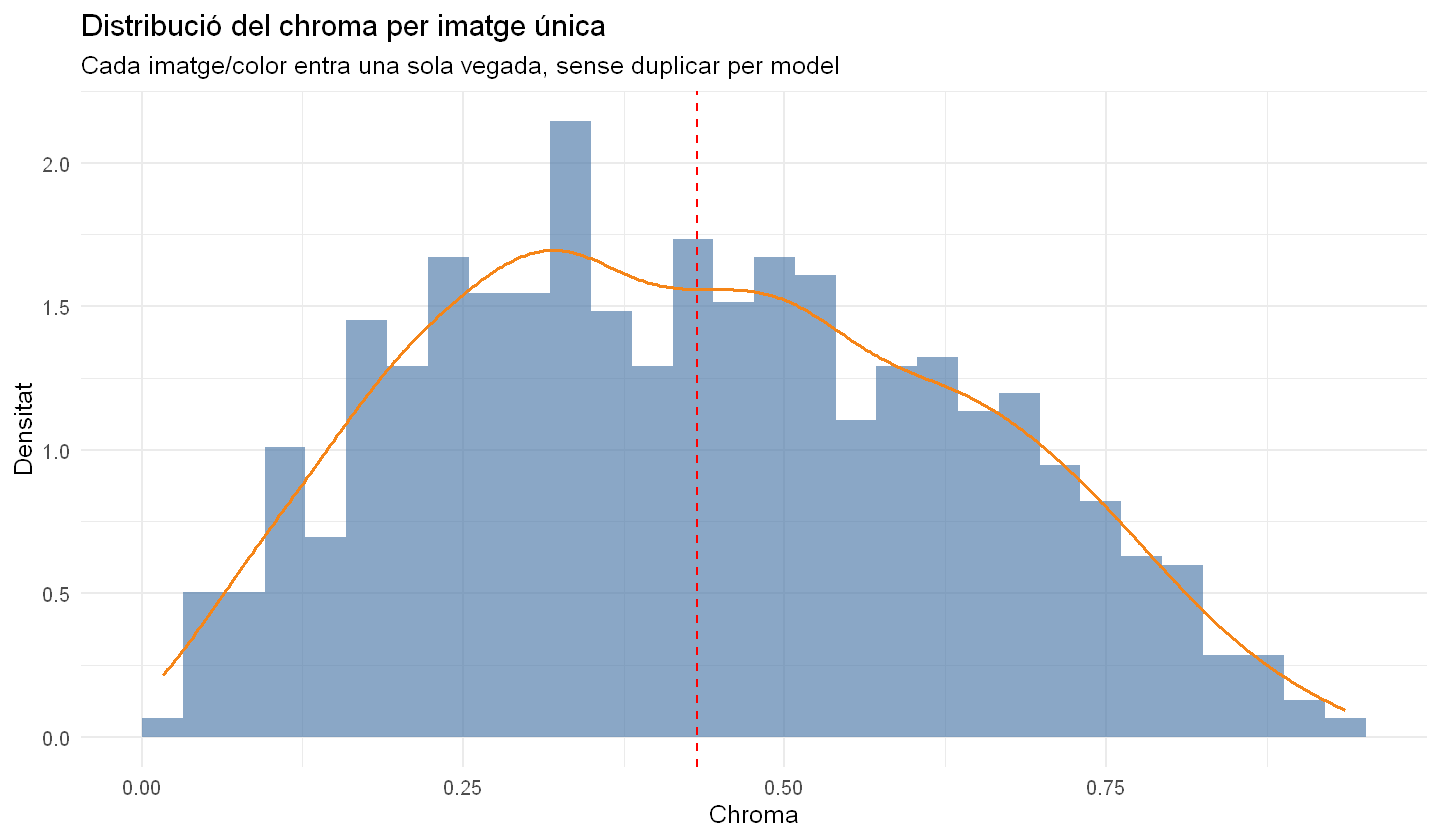

In [11]:
# Descripcio del chroma per imatge/color unic.
# El chroma es una caracterestica de la imatge, no del model; per aixo no es dupliquen les dues files de cada parella.
dades_chroma <- dades_models %>%
  distinct(image_name, hex, chroma)

resum_chroma <- dades_chroma %>%
  summarise(
    n_imatges = n(),
    minim = min(chroma, na.rm = TRUE),
    q1 = quantile(chroma, 0.25, na.rm = TRUE),
    mediana = median(chroma, na.rm = TRUE),
    mitjana = mean(chroma, na.rm = TRUE),
    q3 = quantile(chroma, 0.75, na.rm = TRUE),
    maxim = max(chroma, na.rm = TRUE),
    sd = sd(chroma, na.rm = TRUE)
  )

taula(resum_chroma, digits = 4, caption = "Distribucio del chroma per imatge unica")

ggplot(dades_chroma, aes(x = chroma)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "#4C78A8", alpha = 0.65) +
  geom_density(color = "#F58518", linewidth = 1.1) +
  geom_vline(aes(xintercept = mean(chroma, na.rm = TRUE)), color = "red", linetype = "dashed") +
  labs(
    title = "Distribució del chroma per imatge única",
    subtitle = "Cada imatge/color entra una sola vegada, sense duplicar per model",
    x = "Chroma",
    y = "Densitat"
  )

### 3.3. Procediment

El pipeline aplicat és:

1. lectura de dades;
2. neteja i comprovació de columnes;
3. filtratge dels models **gpt-5.1** i **gpt-5.4**;
4. comprovació de l'aparellament per `image_name`;
5. estadística descriptiva;
6. anàlisi bivariant entre `chroma` i error;
7. validació visual de premisses;
8. contrast t aparellat;
9. models lineals;
10. interpretació aplicada dels resultats.


### 3.3.1. Control de qualitat i comparabilitat de la mostra


In [12]:
# Control de qualitat específic dels dos models.
qualitat_models <- dades_models %>%
  group_by(model) %>%
  summarise(
    observacions = n(),
    imatges_uniques = n_distinct(image_name),
    colors_objectiu_unics = n_distinct(hex),
    respostes_uniques = n_distinct(response_hex),
    valors_perduts_error = sum(is.na(error_cromatic)),
    valors_perduts_chroma = sum(is.na(chroma)),
    duplicats_image_model = sum(duplicated(paste(image_name, model))),
    minim_error = min(error_cromatic, na.rm = TRUE),
    maxim_error = max(error_cromatic, na.rm = TRUE),
    minim_chroma = min(chroma, na.rm = TRUE),
    maxim_chroma = max(chroma, na.rm = TRUE),
    .groups = "drop"
  )

taula(qualitat_models, digits = 4, caption = "Control de qualitat i comparabilitat per model")


model,observacions,imatges_uniques,colors_objectiu_unics,respostes_uniques,valors_perduts_error,valors_perduts_chroma,duplicats_image_model,minim_error,maxim_error,minim_chroma,maxim_chroma
gpt-5.1,1000,1000,1000,984,0,0,0,1.0000,111.2025,0.0165,0.9363
gpt-5.4,1000,1000,1000,976,0,0,0,2.2361,232.5812,0.0165,0.9363


model,mitjana_chroma,mediana_chroma,sd_chroma
gpt-5.1,0.4321,0.419,0.2055
gpt-5.4,0.4321,0.419,0.2055


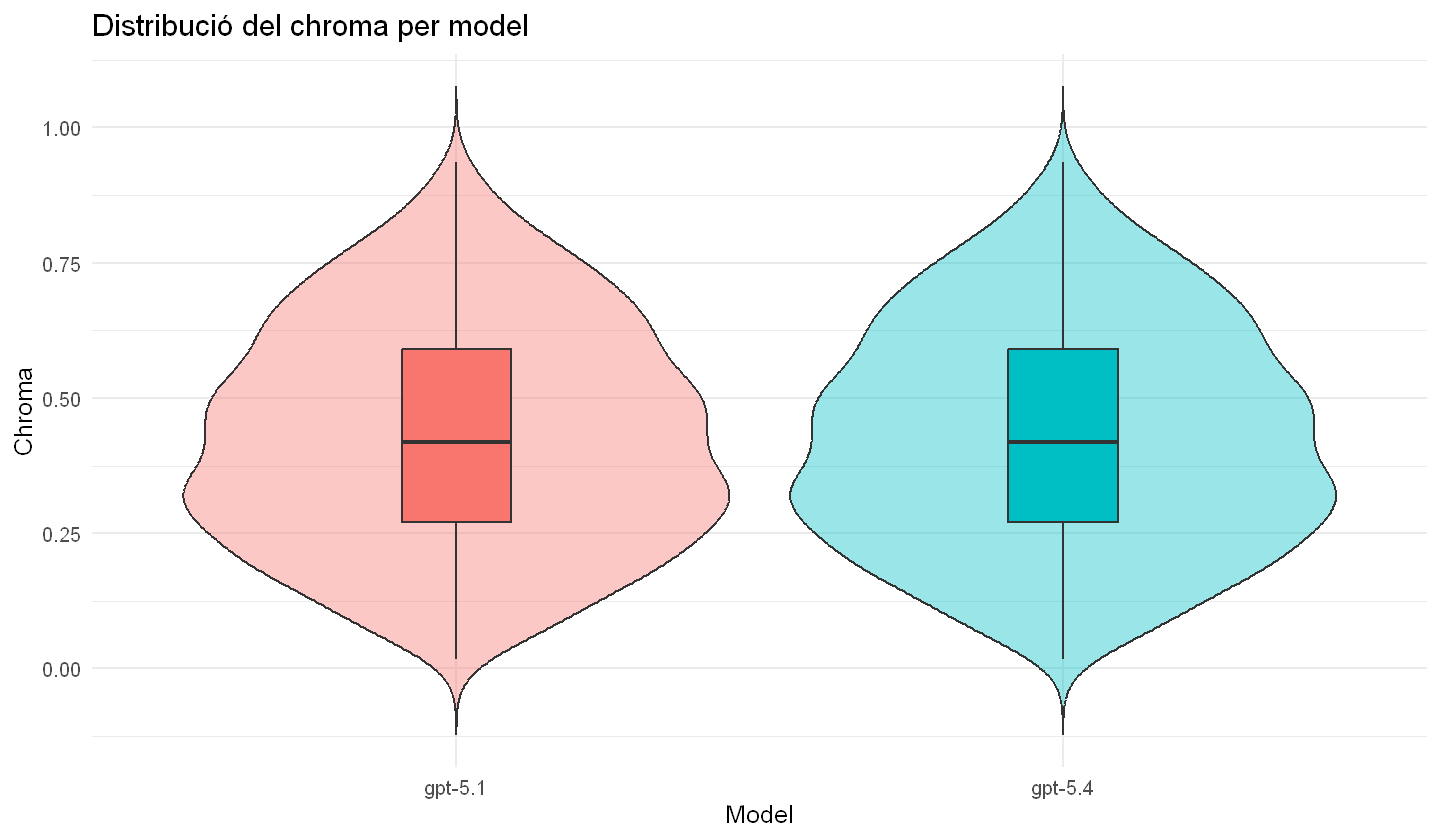

In [13]:
# Comparació del chroma per model. Si la mostra és aparellada, hauria de ser pràcticament idèntic.
chroma_per_model <- dades_models %>%
  group_by(model) %>%
  summarise(
    mitjana_chroma = mean(chroma, na.rm = TRUE),
    mediana_chroma = median(chroma, na.rm = TRUE),
    sd_chroma = sd(chroma, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(dades_models, aes(x = model, y = chroma, fill = model)) +
  geom_violin(alpha = 0.4, trim = FALSE) +
  geom_boxplot(width = 0.18, outlier.alpha = 0.25) +
  labs(
    title = "Distribució del chroma per model",
    x = "Model",
    y = "Chroma"
  ) +
  guides(fill = "none")

taula(chroma_per_model, digits = 4, caption = "Resum del chroma per model")


**Interpretació aplicada.** Com que els models s'apliquen sobre les mateixes imatges, la distribució del `chroma` hauria de ser equivalent entre models. Les diferències en l'error no s'haurien d'atribuir a una mostra de colors diferent, sinó al comportament dels models o a altres factors no registrats al CSV.


## 3.4. Anàlisi estadístic

### 3.4.1. Estadística descriptiva


In [14]:
# Estadística descriptiva de l'error per model.
descriptiva_error <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    mitjana = mean(error_cromatic, na.rm = TRUE),
    mediana = median(error_cromatic, na.rm = TRUE),
    desviacio_tipica = sd(error_cromatic, na.rm = TRUE),
    variancia = var(error_cromatic, na.rm = TRUE),
    minim = min(error_cromatic, na.rm = TRUE),
    q1 = quantile(error_cromatic, 0.25, na.rm = TRUE),
    q3 = quantile(error_cromatic, 0.75, na.rm = TRUE),
    iqr = IQR(error_cromatic, na.rm = TRUE),
    maxim = max(error_cromatic, na.rm = TRUE),
    .groups = "drop"
  )

taula(descriptiva_error, digits = 4, caption = "Estadística descriptiva de l'error cromàtic per model")


model,n,mitjana,mediana,desviacio_tipica,variancia,minim,q1,q3,iqr,maxim
gpt-5.1,1000,26.9591,24.8395,13.9302,194.0509,1.0000,16.5756,35.5281,18.9526,111.2025
gpt-5.4,1000,47.6172,43.7664,25.0463,627.3188,2.2361,30.5614,60.2785,29.7171,232.5812


**Interpretació aplicada.** Aquesta taula permet comparar el nivell mitjà d'error i la dispersió de cada model. Una mitjana menor indica millor precisió cromàtica; una desviació típica menor indica més estabilitat.


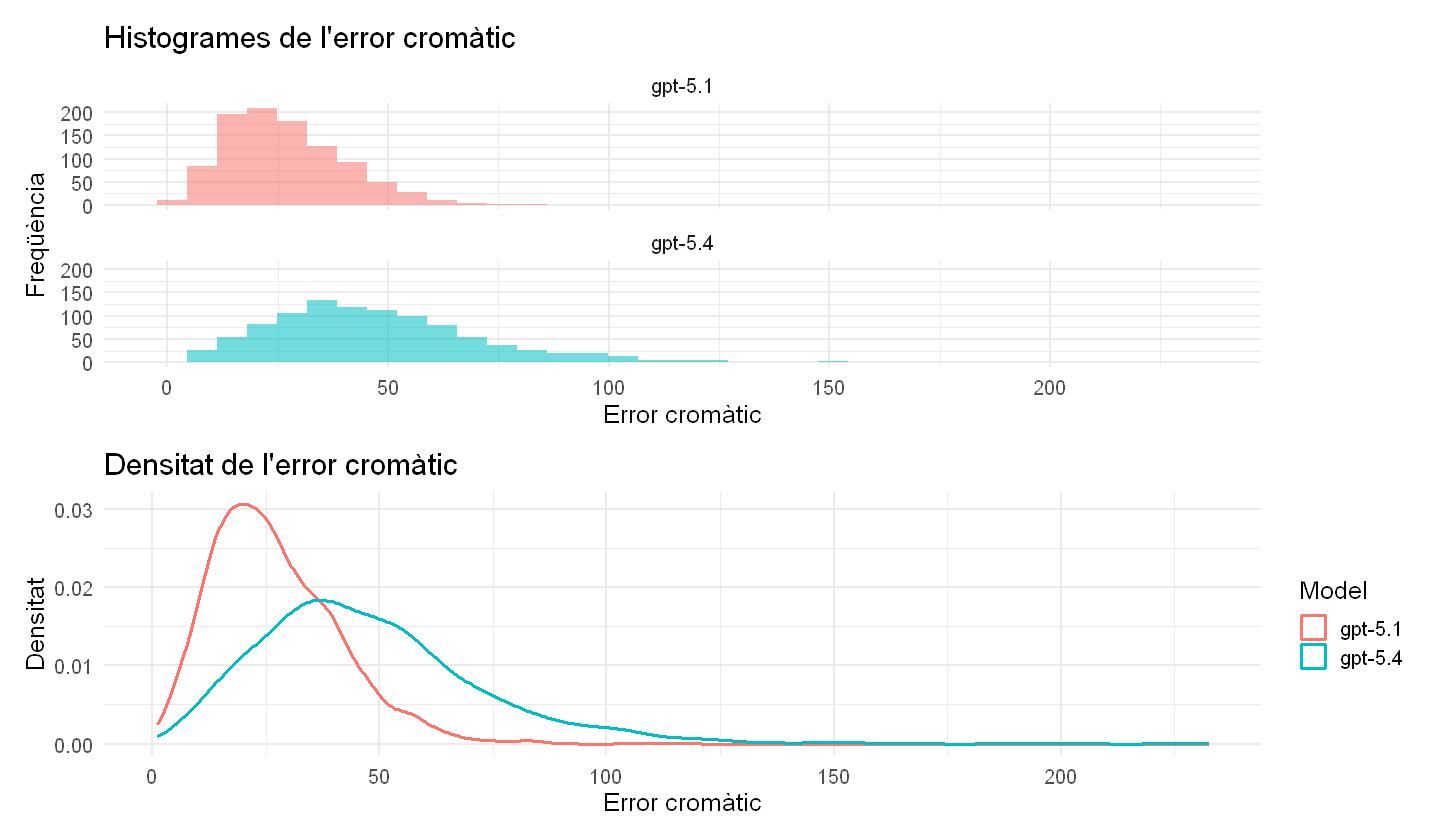

In [15]:
# Histogrames i densitats de l'error.
graf_hist <- ggplot(dades_models, aes(x = error_cromatic, fill = model)) +
  geom_histogram(alpha = 0.55, bins = 35, position = "identity") +
  facet_wrap(~ model, ncol = 1) +
  labs(
    title = "Histogrames de l'error cromàtic",
    x = "Error cromàtic",
    y = "Freqüència"
  ) +
  guides(fill = "none")

graf_densitat <- ggplot(dades_models, aes(x = error_cromatic, color = model)) +
  geom_density(linewidth = 1) +
  labs(
    title = "Densitat de l'error cromàtic",
    x = "Error cromàtic",
    y = "Densitat",
    color = "Model"
  )

graf_hist / graf_densitat


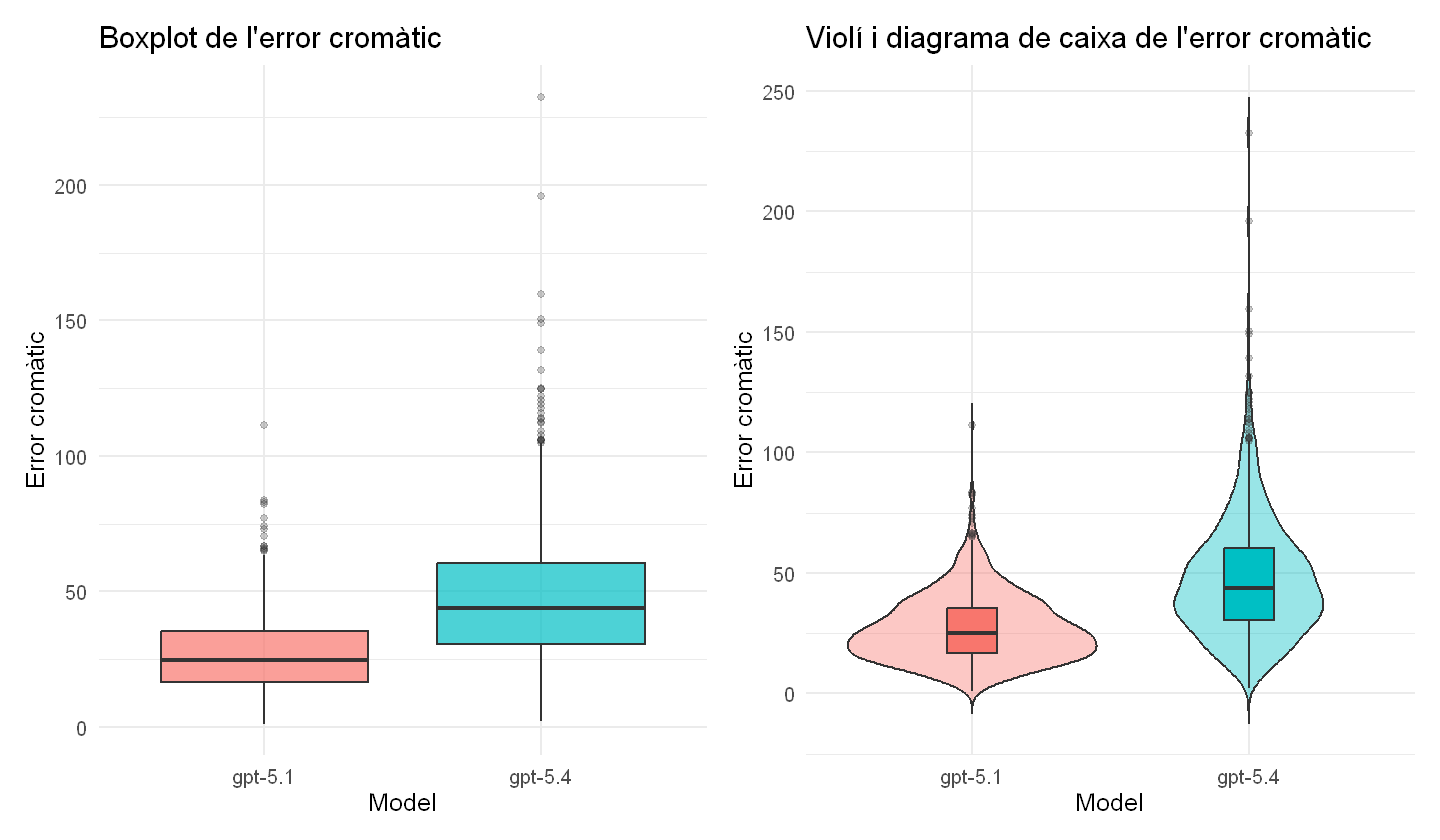

In [16]:
# Boxplots i violí + boxplot.
graf_boxplot <- ggplot(dades_models, aes(x = model, y = error_cromatic, fill = model)) +
  geom_boxplot(alpha = 0.7, outlier.alpha = 0.25) +
  labs(
    title = "Boxplot de l'error cromàtic",
    x = "Model",
    y = "Error cromàtic"
  ) +
  guides(fill = "none")

graf_violi <- ggplot(dades_models, aes(x = model, y = error_cromatic, fill = model)) +
  geom_violin(alpha = 0.4, trim = FALSE) +
  geom_boxplot(width = 0.18, outlier.alpha = 0.25) +
  labs(
    title = "Violí i diagrama de caixa de l'error cromàtic",
    x = "Model",
    y = "Error cromàtic"
  ) +
  guides(fill = "none")

graf_boxplot + graf_violi


In [17]:
# Concentració de respostes i repeticions.
concentracio_respostes <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    valors_error_unics = n_distinct(error_cromatic),
    ratio_error_unic = valors_error_unics / n,
    respostes_hex_uniques = n_distinct(response_hex),
    ratio_hex_unic = respostes_hex_uniques / n,
    repeticio_maxima_hex = max(table(response_hex)),
    percentatge_respostes_repetides = 100 * (1 - ratio_hex_unic),
    .groups = "drop"
  )

taula(concentracio_respostes, digits = 4, caption = "Concentració de respostes per model")


model,n,valors_error_unics,ratio_error_unic,respostes_hex_uniques,ratio_hex_unic,repeticio_maxima_hex,percentatge_respostes_repetides
gpt-5.1,1000,718,0.718,984,0.984,4,1.6
gpt-5.4,1000,891,0.891,976,0.976,12,2.4


**Interpretació aplicada.** La concentració de respostes permet detectar si un model tendeix a reutilitzar els mateixos colors. Una ràtio baixa de respostes HEX úniques indica més repetició i pot explicar part de l'error.


In [18]:
# Percentatge d'encert segons llindars d'error.
llindars <- c(10, 20, 30, 50)

percentatge_encert <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    exact_hex_pct = 100 * mean(response_hex == hex, na.rm = TRUE),
    err_le_10_pct = 100 * mean(error_cromatic <= 10, na.rm = TRUE),
    err_le_20_pct = 100 * mean(error_cromatic <= 20, na.rm = TRUE),
    err_le_30_pct = 100 * mean(error_cromatic <= 30, na.rm = TRUE),
    err_le_50_pct = 100 * mean(error_cromatic <= 50, na.rm = TRUE),
    .groups = "drop"
  )

taula(percentatge_encert, digits = 2, caption = "Percentatge d'encert segons llindars d'error")


model,n,exact_hex_pct,err_le_10_pct,err_le_20_pct,err_le_30_pct,err_le_50_pct
gpt-5.1,1000,0,7.7,35.8,64.3,93.7
gpt-5.4,1000,0,2.0,10.5,24.1,59.8


**Interpretació aplicada.** Els llindars mostren la proporció de prediccions amb error petit o moderat. Aquesta lectura complementa la mitjana, perquè mostra si un model concentra més observacions prop del color real.


### 3.4.2. Anàlisi bivariant


In [19]:
# Correlació entre chroma i error per model.
correlacio_chroma_error <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    correlacio = cor(chroma, error_cromatic, use = "complete.obs"),
    .groups = "drop"
  )

taula(correlacio_chroma_error, digits = 4, caption = "Correlació entre chroma i error cromàtic")


model,n,correlacio
gpt-5.1,1000,0.2439
gpt-5.4,1000,-0.0356


`geom_smooth()` using formula = 'y ~ x'


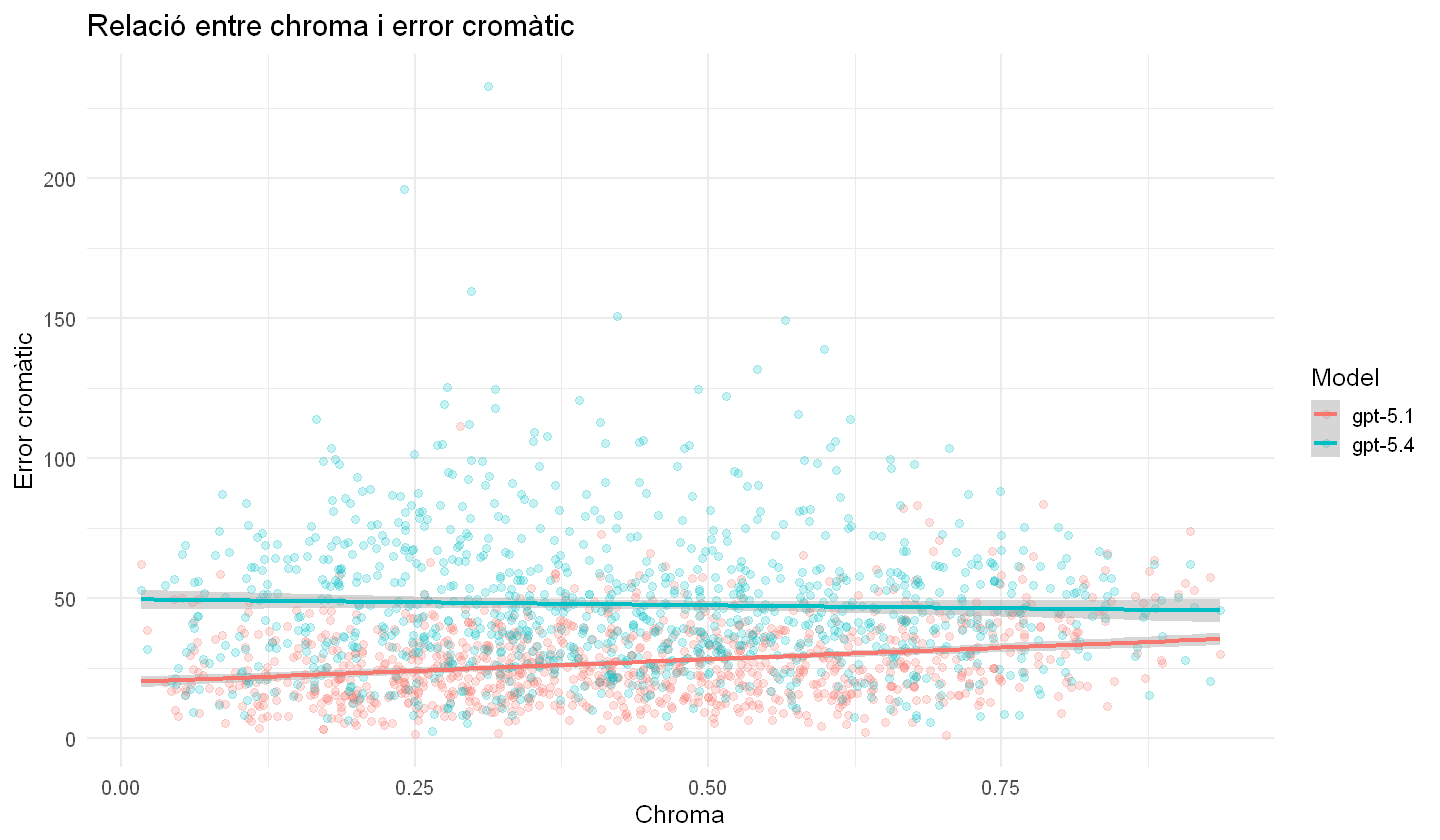

In [20]:
# Gràfic error vs chroma amb regressió visual.
ggplot(dades_models, aes(x = chroma, y = error_cromatic, color = model)) +
  geom_point(alpha = 0.22) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Relació entre chroma i error cromàtic",
    x = "Chroma",
    y = "Error cromàtic",
    color = "Model"
  )


model,bucket_chroma,n,error_mitja,error_mediana
gpt-5.1,baix,250,23.1037,20.6881
gpt-5.1,mitja-baix,250,26.6496,24.9999
gpt-5.1,mitja-alt,250,26.4027,24.7378
gpt-5.1,alt,250,31.6804,29.1290
gpt-5.4,baix,250,47.9688,45.7387
gpt-5.4,mitja-baix,250,49.4190,44.3000
gpt-5.4,mitja-alt,250,47.3163,42.2255
gpt-5.4,alt,250,45.7648,44.5028


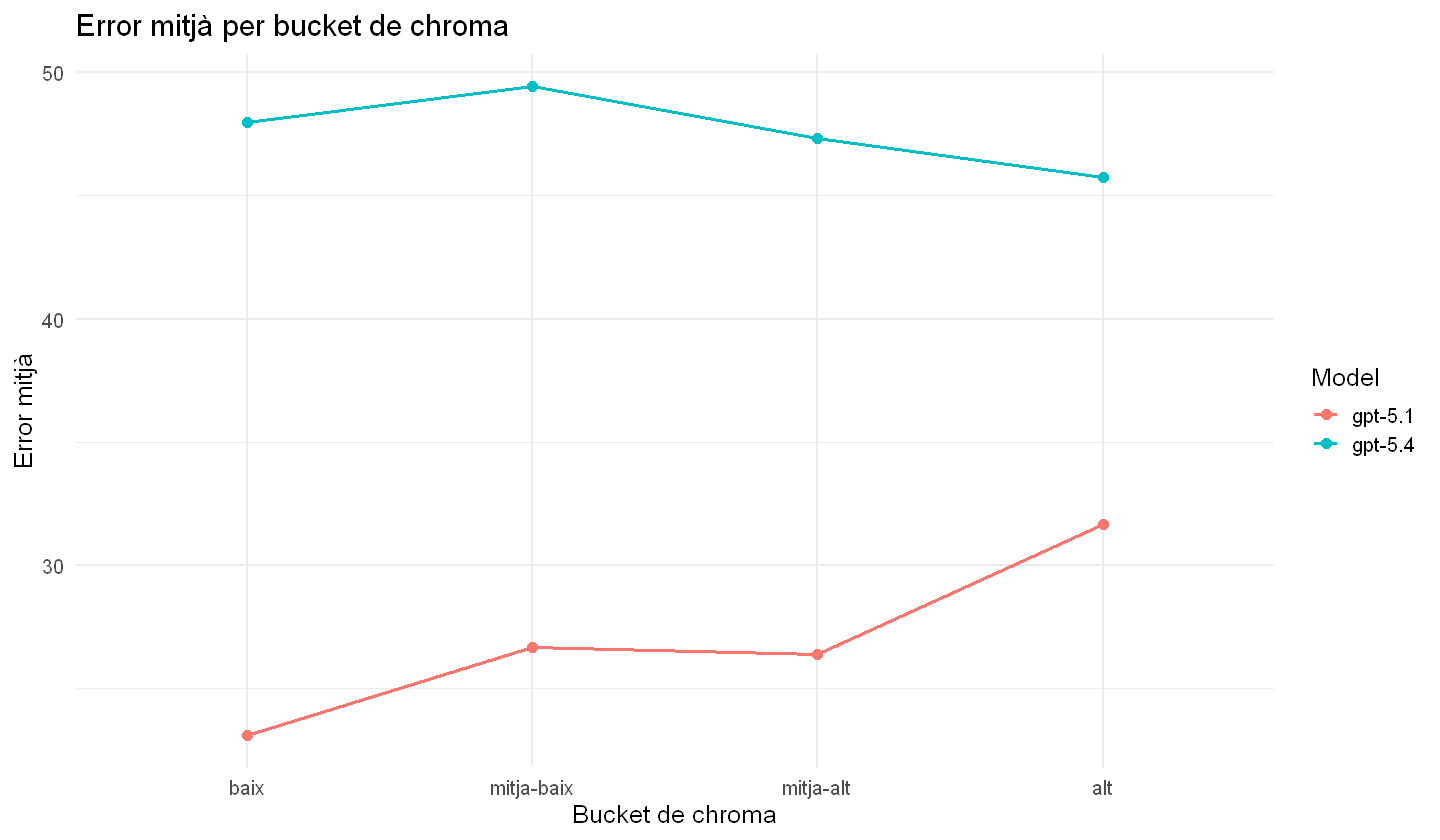

In [21]:
# Creació de 4 buckets de chroma per quartils.
dades_models <- dades_models %>%
  mutate(
    bucket_chroma = ntile(chroma, 4),
    bucket_chroma = factor(
      bucket_chroma,
      levels = 1:4,
      labels = c("baix", "mitja-baix", "mitja-alt", "alt")
    )
  )

resum_buckets <- dades_models %>%
  group_by(model, bucket_chroma) %>%
  summarise(
    n = n(),
    error_mitja = mean(error_cromatic, na.rm = TRUE),
    error_mediana = median(error_cromatic, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(resum_buckets, aes(x = bucket_chroma, y = error_mitja, group = model, color = model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2.5) +
  labs(
    title = "Error mitjà per bucket de chroma",
    x = "Bucket de chroma",
    y = "Error mitjà",
    color = "Model"
  )

taula(resum_buckets, digits = 4, caption = "Error mitjà per bucket de chroma")


**Interpretació aplicada.** Aquesta anàlisi indica si l'error varia amb la saturació del color. Si l'error mitjà augmenta als buckets de chroma alt, els colors més saturats són més difícils per al model en aquest dataset.


### 3.4.3. Validació de premisses


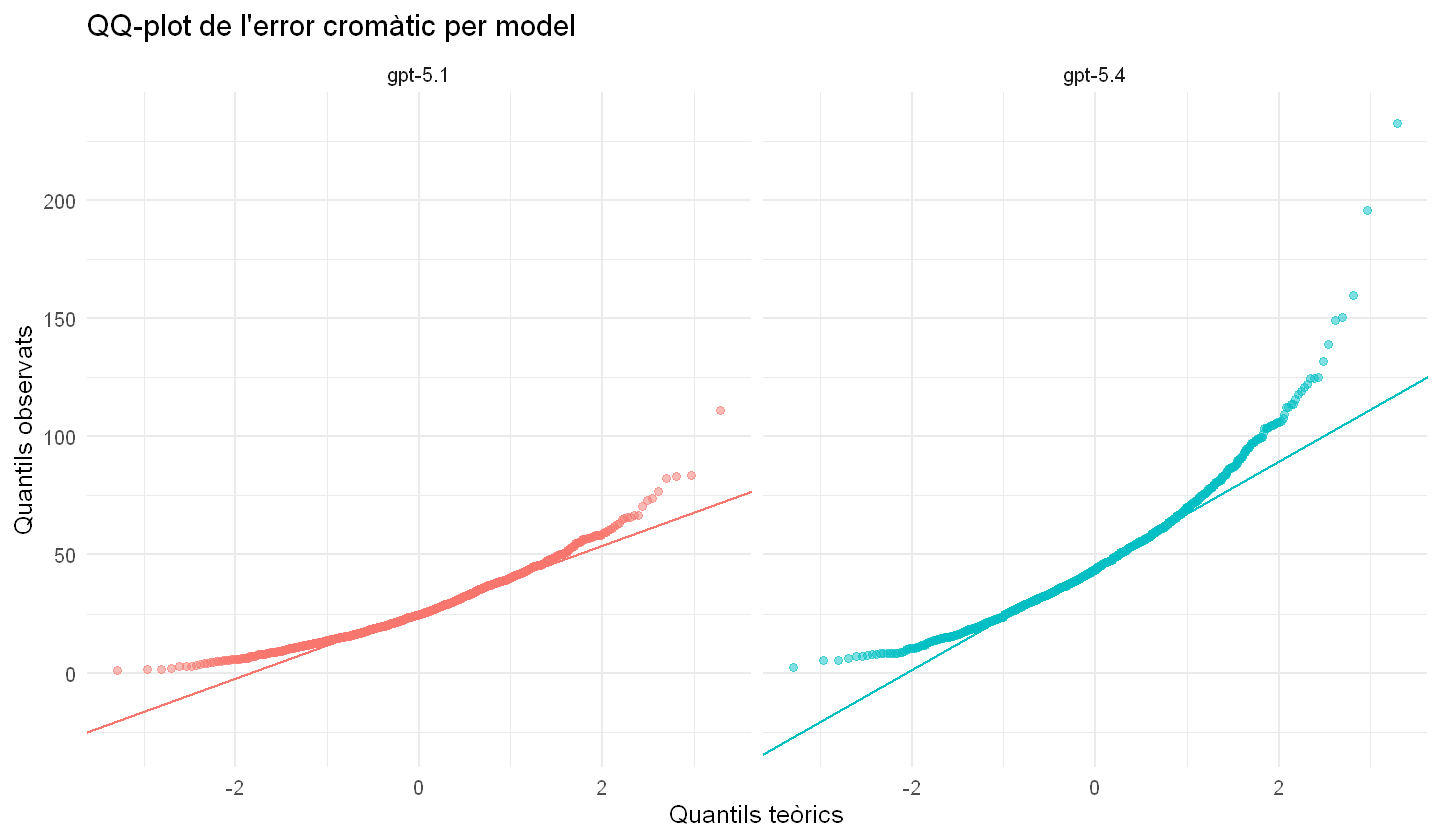

In [22]:
# QQ-plot de l'error per model.
ggplot(dades_models, aes(sample = error_cromatic, color = model)) +
  stat_qq(alpha = 0.5) +
  stat_qq_line() +
  facet_wrap(~ model) +
  labs(
    title = "QQ-plot de l'error cromàtic per model",
    x = "Quantils teòrics",
    y = "Quantils observats",
    color = "Model"
  ) +
  guides(color = "none")


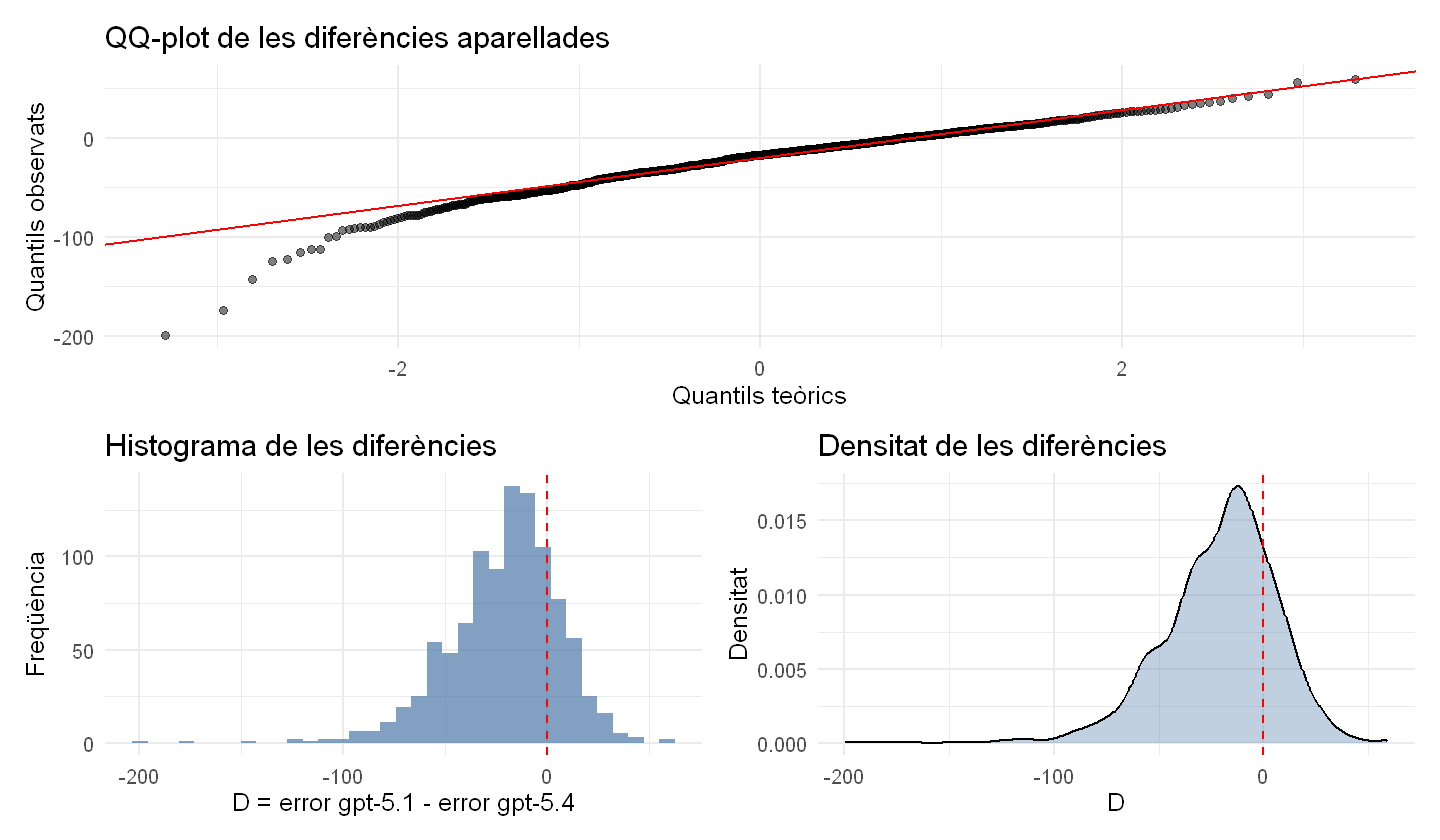

In [23]:
# QQ-plot, histograma i densitat de les diferències aparellades.
graf_qq_D <- ggplot(dades_aparellades, aes(sample = D)) +
  stat_qq(alpha = 0.5) +
  stat_qq_line(color = "red") +
  labs(
    title = "QQ-plot de les diferències aparellades",
    x = "Quantils teòrics",
    y = "Quantils observats"
  )

graf_hist_D <- ggplot(dades_aparellades, aes(x = D)) +
  geom_histogram(bins = 35, fill = "#4C78A8", alpha = 0.7) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = "Histograma de les diferències",
    x = "D = error gpt-5.1 - error gpt-5.4",
    y = "Freqüència"
  )

graf_dens_D <- ggplot(dades_aparellades, aes(x = D)) +
  geom_density(fill = "#4C78A8", alpha = 0.35) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = "Densitat de les diferències",
    x = "D",
    y = "Densitat"
  )

graf_qq_D / (graf_hist_D + graf_dens_D)


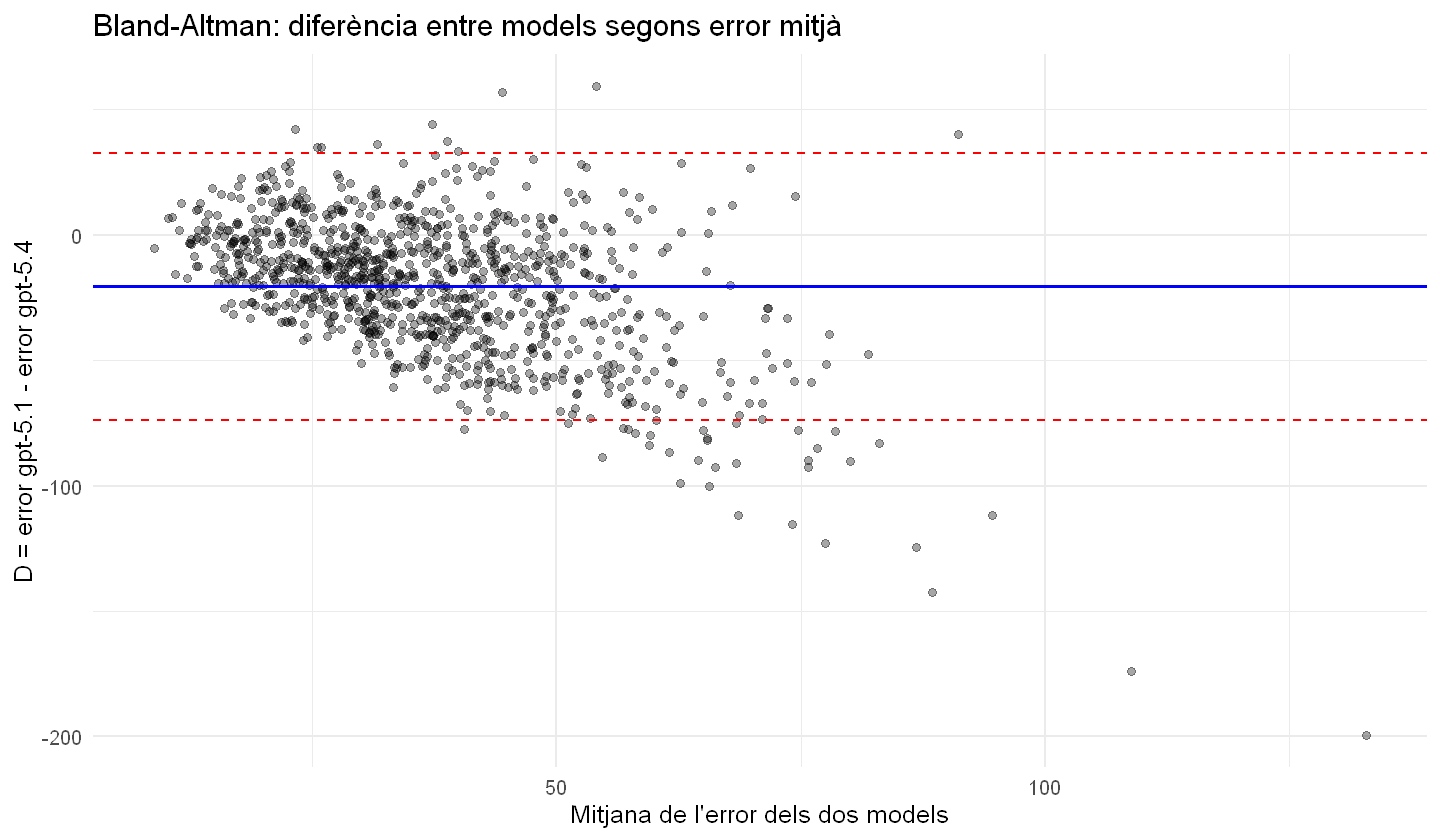

In [24]:
# Bland-Altman plot.
ggplot(dades_aparellades, aes(x = mitjana_parella, y = D)) +
  geom_point(alpha = 0.35) +
  geom_hline(yintercept = mean(dades_aparellades$D), color = "blue", linewidth = 1) +
  geom_hline(
    yintercept = mean(dades_aparellades$D) + 1.96 * sd(dades_aparellades$D),
    linetype = "dashed",
    color = "red"
  ) +
  geom_hline(
    yintercept = mean(dades_aparellades$D) - 1.96 * sd(dades_aparellades$D),
    linetype = "dashed",
    color = "red"
  ) +
  labs(
    title = "Bland-Altman: diferència entre models segons error mitjà",
    x = "Mitjana de l'error dels dos models",
    y = "D = error gpt-5.1 - error gpt-5.4"
  )


**Interpretació aplicada.** Els gràfics anteriors s'utilitzen per revisar si el contrast aparellat és raonable en aquest dataset. El QQ-plot de \(D\) és el més rellevant per al t-test aparellat. El Bland-Altman permet veure si la diferència entre models canvia quan el nivell mitjà d'error és més alt.


### 3.4.4. Contrast d'hipòtesis


In [25]:
# Contrast t aparellat.
test_t_aparellat <- t.test(
  dades_aparellades$error_5_1,
  dades_aparellades$error_5_4,
  paired = TRUE
)

# Sortida nativa de R del t-test.
print(test_t_aparellat)

# Valors guardats per a interpretacions posteriors.
diferencia_mitjana <- unname(test_t_aparellat$estimate)
ic_95 <- test_t_aparellat$conf.int
p_value_t <- test_t_aparellat$p.value
model_millor <- ifelse(diferencia_mitjana < 0, model_a, model_b)


	Paired t-test

data:  dades_aparellades$error_5_1 and dades_aparellades$error_5_4
t = -24.002, df = 999, p-value < 0.00000000000000022
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -22.34709 -18.96914
sample estimates:
mean difference 
      -20.65812 



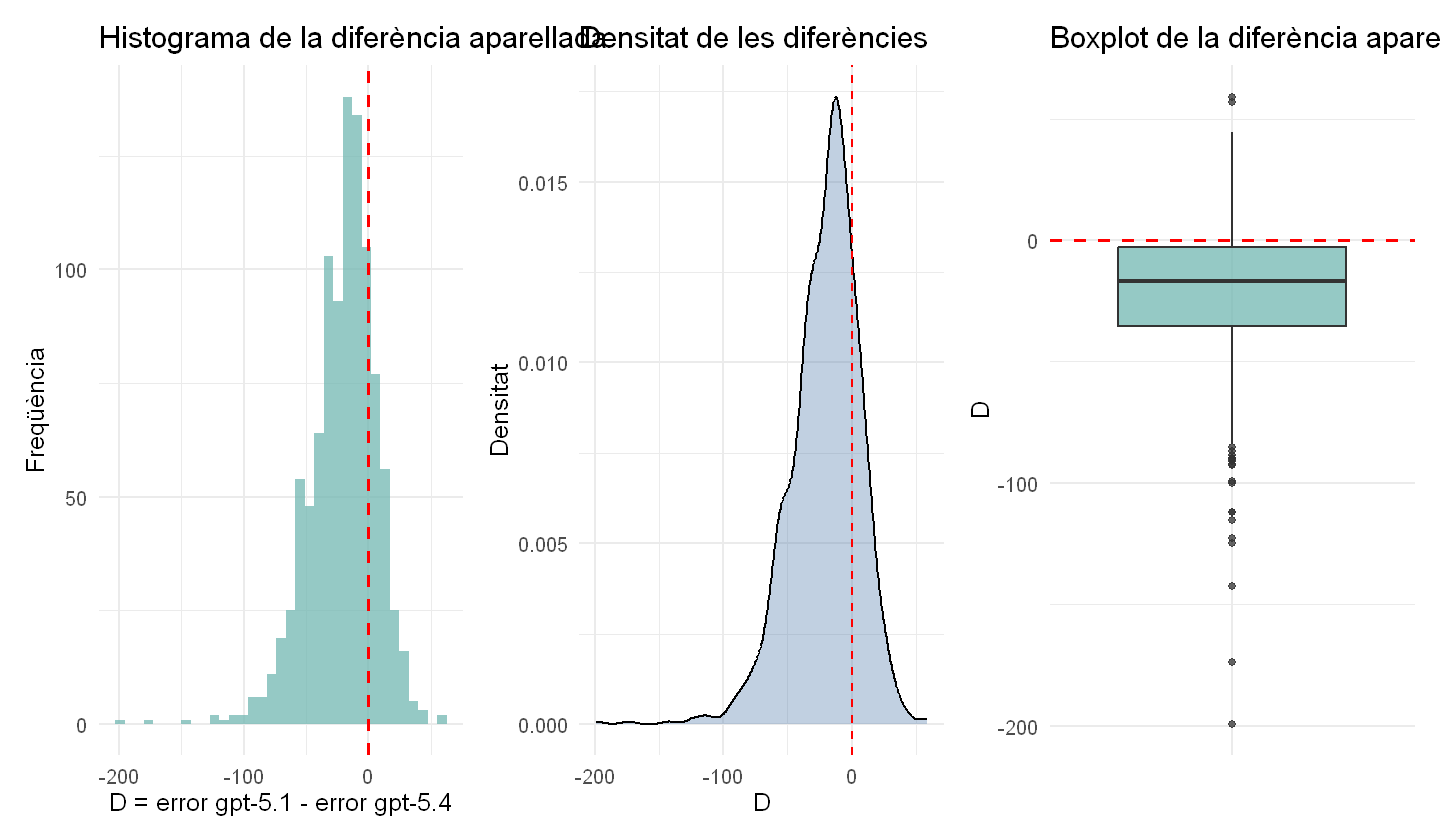

In [26]:
# Gràfics de les diferències amb línia vertical a zero.
graf_diff_hist <- ggplot(dades_aparellades, aes(x = D)) +
  geom_histogram(bins = 35, fill = "#72B7B2", alpha = 0.75) +
  geom_vline(xintercept = 0, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Histograma de la diferència aparellada",
    x = "D = error gpt-5.1 - error gpt-5.4",
    y = "Freqüència"
  )

graf_diff_box <- ggplot(dades_aparellades, aes(y = D, x = "")) +
  geom_boxplot(fill = "#72B7B2", alpha = 0.75) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Boxplot de la diferència aparellada",
    x = "",
    y = "D"
  )

graf_diff_hist + graf_dens_D + graf_diff_box


**Interpretació aplicada.** Si \(D\) és negativa, l'error de **gpt-5.1** és menor que el de **gpt-5.4** en mitjana. Si l'interval de confiança de \(D\) no inclou zero, hi ha evidència estadística de diferència entre models.


### 3.4.5. Comparació de variabilitat


model,n,desviacio_tipica,variancia,iqr,rang
gpt-5.1,1000,13.9302,194.0509,18.9526,110.2025
gpt-5.4,1000,25.0463,627.3188,29.7171,230.3451


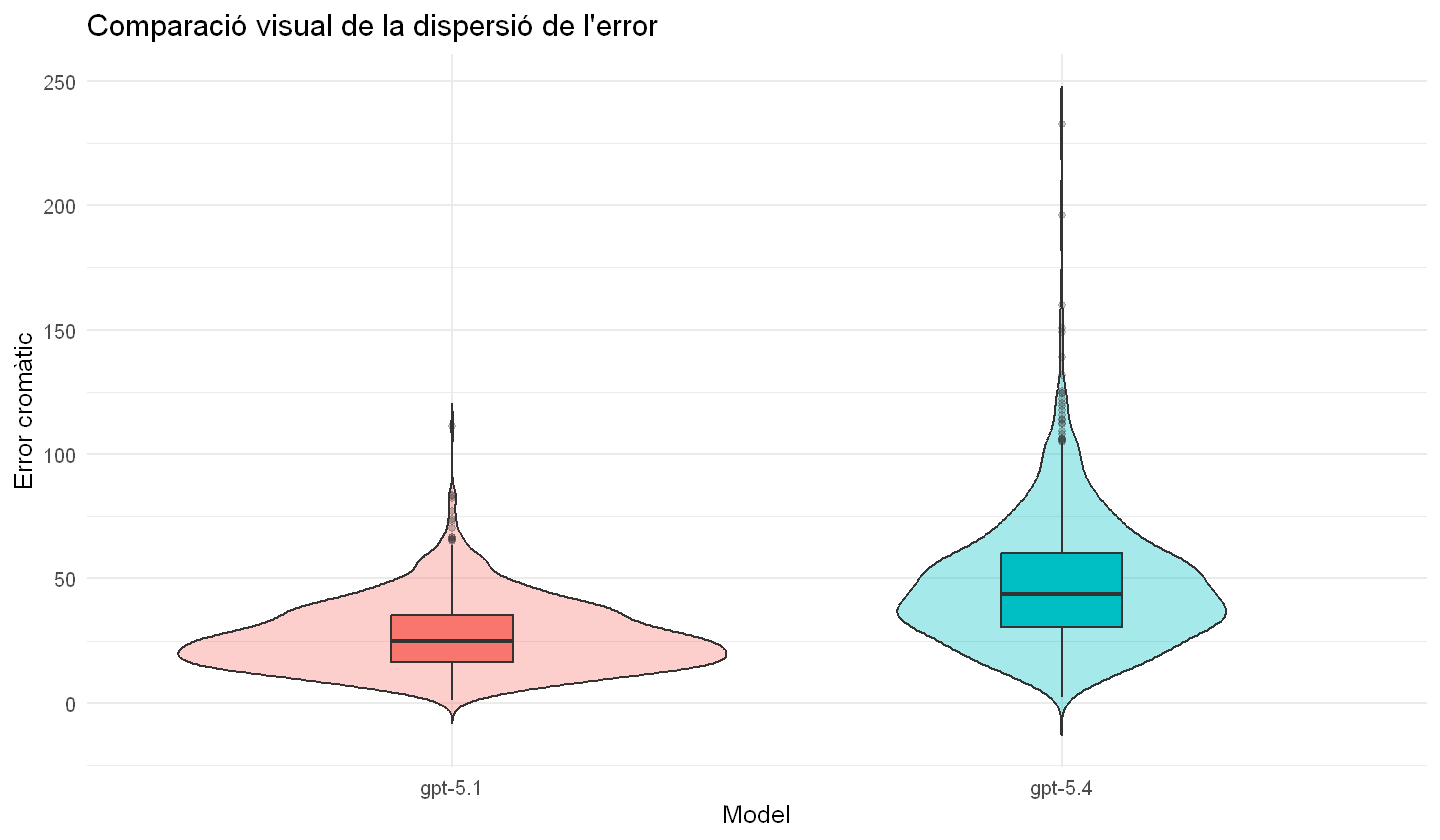

In [27]:
# Comparació descriptiva de desviacions típiques i variàncies.
variabilitat <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    desviacio_tipica = sd(error_cromatic, na.rm = TRUE),
    variancia = var(error_cromatic, na.rm = TRUE),
    iqr = IQR(error_cromatic, na.rm = TRUE),
    rang = max(error_cromatic, na.rm = TRUE) - min(error_cromatic, na.rm = TRUE),
    .groups = "drop"
  )

taula(variabilitat, digits = 4, caption = "Comparació descriptiva de variabilitat")

ggplot(dades_models, aes(x = model, y = error_cromatic, fill = model)) +
  geom_violin(alpha = 0.35, trim = FALSE) +
  geom_boxplot(width = 0.2, outlier.alpha = 0.25) +
  labs(
    title = "Comparació visual de la dispersió de l'error",
    x = "Model",
    y = "Error cromàtic"
  ) +
  guides(fill = "none")


**Interpretació aplicada.** Aquesta comparació és descriptiva. El model amb menor desviació típica, menor variància i una caixa més compacta al gràfic es pot considerar més estable en aquest dataset.


### 3.4.6. Models estadístics

#### A) Model per diferència aparellada


In [28]:
# Model de la diferencia aparellada: lm(D ~ 1).
model_D <- lm(D ~ 1, data = dades_aparellades)

# Sortida nativa de R del model.
summary(model_D)


Call:
lm(formula = D ~ 1, data = dades_aparellades)

Residuals:
     Min       1Q   Median       3Q      Max 
-178.742  -14.785    3.616   17.867   79.720 

Coefficients:
            Estimate Std. Error t value            Pr(>|t|)    
(Intercept) -20.6581     0.8607     -24 <0.0000000000000002 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 27.22 on 999 degrees of freedom


**Interpretació aplicada.** L'intercept del model `lm(D ~ 1)` és la diferència mitjana entre els dos models. Coincideix amb l'estimació del t-test aparellat perquè tots dos contrasten si la diferència mitjana és zero.


#### B) Model lineal simple

En aquest apartat nomes ajustem el model lineal simple que s'ha vist a classe, separat per a cada model:

$$error\_cromatic \sim chroma$$

La sortida que es mostra es la sortida nativa de R amb `summary(lm(...))`.

In [29]:
# Model lineal simple per a gpt-5.1.
model_simple_5_1 <- lm(
  error_cromatic ~ chroma,
  data = dades_models %>% filter(model == "gpt-5.1")
)

summary(model_simple_5_1)

# Model lineal simple per a gpt-5.4.
model_simple_5_4 <- lm(
  error_cromatic ~ chroma,
  data = dades_models %>% filter(model == "gpt-5.4")
)

summary(model_simple_5_4)


Call:
lm(formula = error_cromatic ~ chroma, data = dades_models %>% 
    filter(model == "gpt-5.1"))

Residuals:
    Min      1Q  Median      3Q     Max 
-30.441  -9.719  -1.891   8.142  86.610 

Coefficients:
            Estimate Std. Error t value             Pr(>|t|)    
(Intercept)  19.8169     0.9955  19.906 < 0.0000000000000002 ***
chroma       16.5276     2.0806   7.944  0.00000000000000528 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 13.52 on 998 degrees of freedom
Multiple R-squared:  0.05947,	Adjusted R-squared:  0.05852 
F-statistic:  63.1 on 1 and 998 DF,  p-value: 0.000000000000005276



Call:
lm(formula = error_cromatic ~ chroma, data = dades_models %>% 
    filter(model == "gpt-5.4"))

Residuals:
    Min      1Q  Median      3Q     Max 
-46.107 -17.202  -3.782  12.543 184.446 

Coefficients:
            Estimate Std. Error t value            Pr(>|t|)    
(Intercept)   49.490      1.845  26.831 <0.0000000000000002 ***
chroma        -4.335      3.855  -1.124               0.261    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 25.04 on 998 degrees of freedom
Multiple R-squared:  0.001265,	Adjusted R-squared:  0.0002646 
F-statistic: 1.264 on 1 and 998 DF,  p-value: 0.2611


`geom_smooth()` using formula = 'y ~ x'


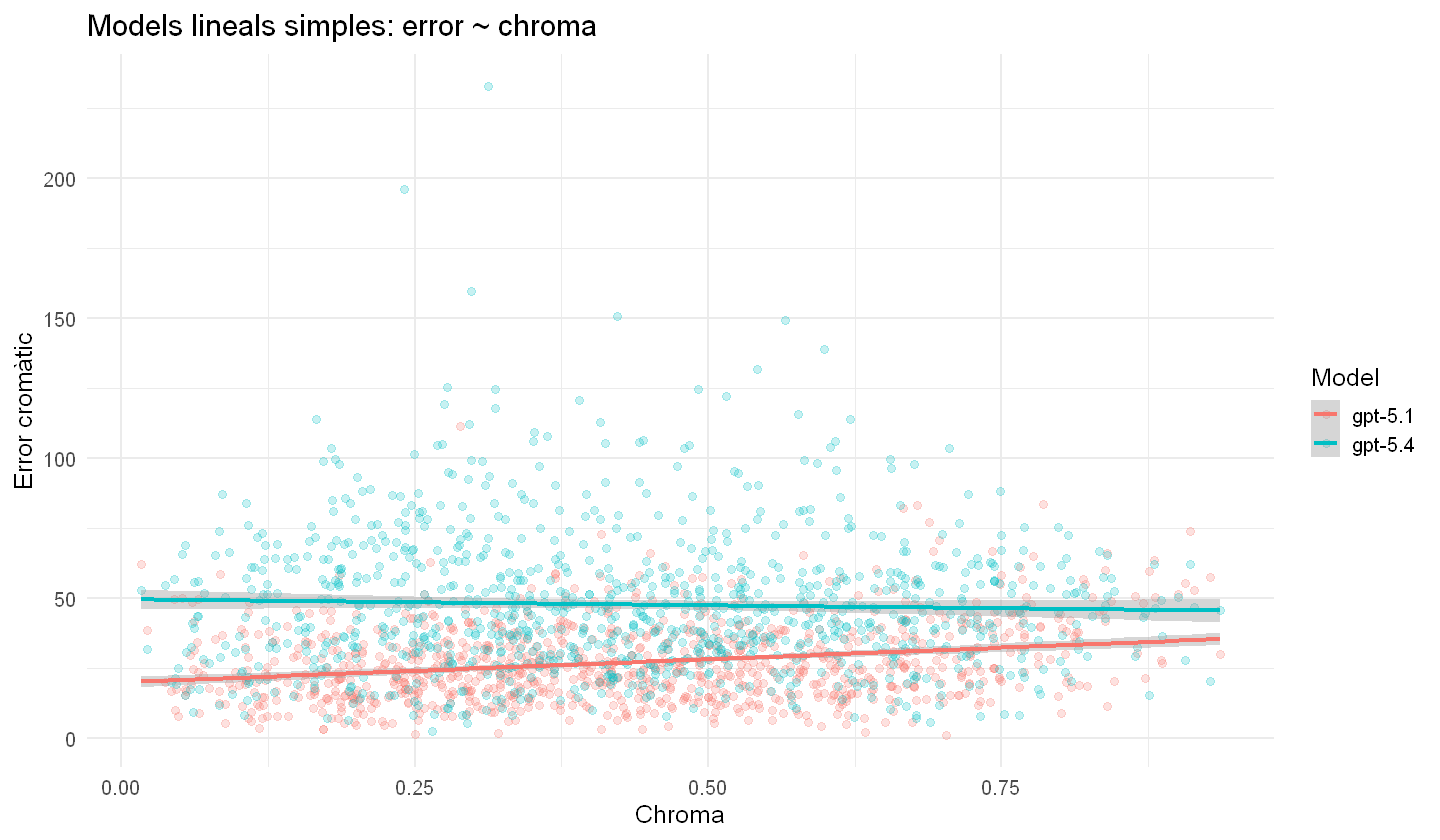

In [30]:
# Gràfic amb rectes de regressió dels models simples.
ggplot(dades_models, aes(x = chroma, y = error_cromatic, color = model)) +
  geom_point(alpha = 0.22) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Models lineals simples: error ~ chroma",
    x = "Chroma",
    y = "Error cromàtic",
    color = "Model"
  )


**Interpretació aplicada.** La pendent del `chroma` indica com canvia l'error quan augmenta la saturació del color. L'R² mostra quina part de la variabilitat de l'error queda explicada només pel `chroma`.


#### C) Model lineal múltiple


In [31]:
# Model lineal multiple en escala original: error ~ chroma + model.
model_multiple <- lm(error_cromatic ~ chroma + model, data = dades_models)

# Sortida nativa de R del model original.
summary(model_multiple)

# Model lineal multiple en escala logaritmica: log1p(error) ~ chroma + model.
model_multiple_log <- lm(log1p(error_cromatic) ~ chroma + model, data = dades_models)

# Sortida nativa de R del model logaritmic.
summary(model_multiple_log)


Call:
lm(formula = error_cromatic ~ chroma + model, data = dades_models)

Residuals:
    Min      1Q  Median      3Q     Max 
-44.360 -12.824  -2.892   9.978 185.692 

Coefficients:
             Estimate Std. Error t value             Pr(>|t|)    
(Intercept)   24.3246     1.1467  21.213 < 0.0000000000000002 ***
chroma         6.0965     2.2022   2.768              0.00569 ** 
modelgpt-5.4  20.6581     0.9048  22.832 < 0.0000000000000002 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 20.23 on 1997 degrees of freedom
Multiple R-squared:  0.2094,	Adjusted R-squared:  0.2086 
F-statistic: 264.5 on 2 and 1997 DF,  p-value: < 0.00000000000000022



Call:
lm(formula = log1p(error_cromatic) ~ chroma + model, data = dades_models)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.58431 -0.30586  0.04748  0.37776  1.73986 

Coefficients:
             Estimate Std. Error t value             Pr(>|t|)    
(Intercept)   3.07035    0.03076  99.817 < 0.0000000000000002 ***
chroma        0.29449    0.05907   4.985          0.000000672 ***
modelgpt-5.4  0.55125    0.02427  22.713 < 0.0000000000000002 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.5427 on 1997 degrees of freedom
Multiple R-squared:  0.2131,	Adjusted R-squared:  0.2123 
F-statistic: 270.4 on 2 and 1997 DF,  p-value: < 0.00000000000000022


escala,mitjana_residu,sd_residu,asimetria_residus,correlacio_abs_residu_ajustat
Original,0,20.221526,1.502142,0.292795
log1p(error),0,0.542432,-0.649661,-0.004845


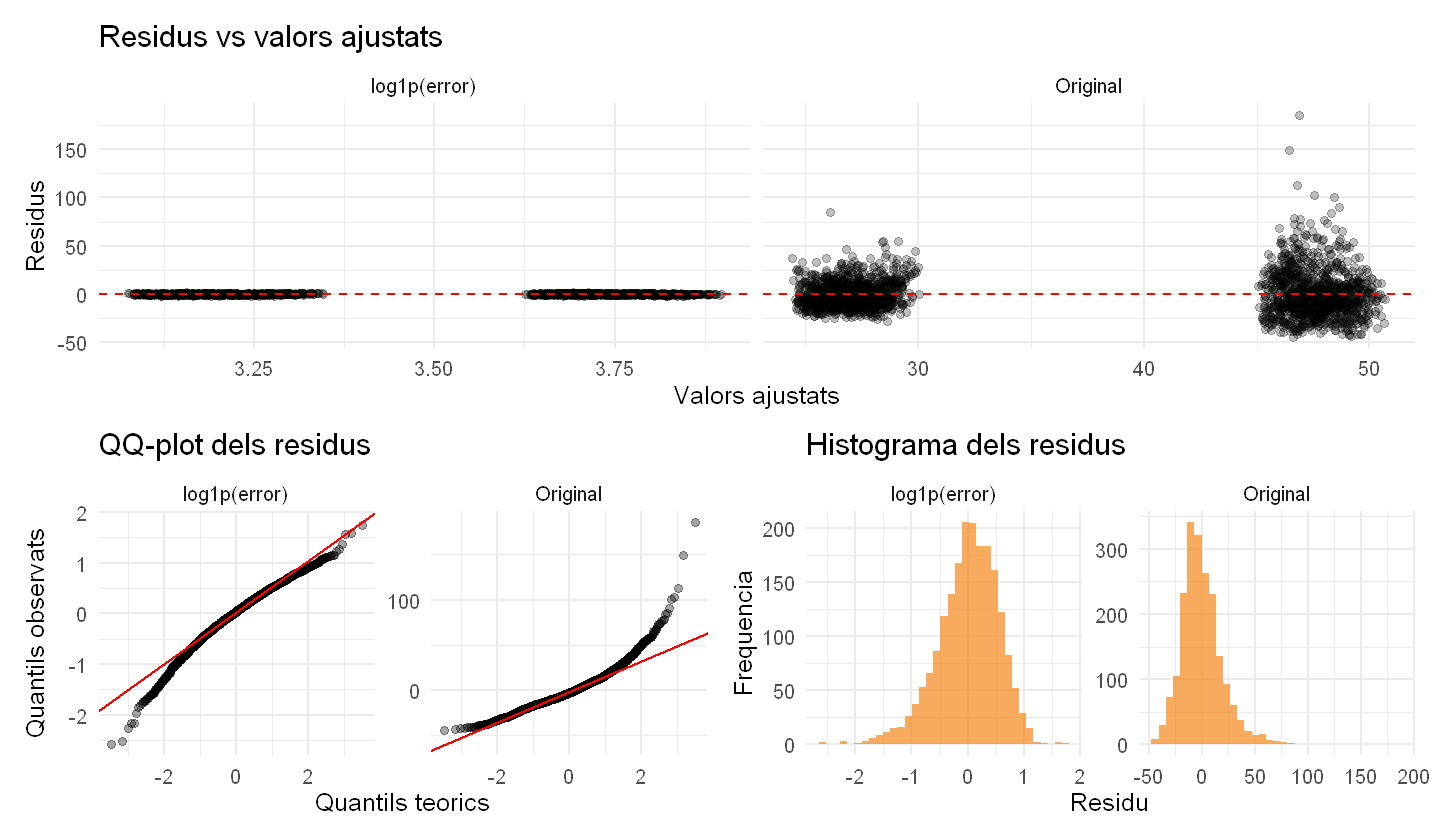

In [32]:
# Diagnostic visual dels models multiples: escala original vs escala logaritmica.
diagnostic_multiple <- tibble(
  escala = "Original",
  ajustats = fitted(model_multiple),
  residus = residuals(model_multiple)
)

diagnostic_multiple_log <- tibble(
  escala = "log1p(error)",
  ajustats = fitted(model_multiple_log),
  residus = residuals(model_multiple_log)
)

diagnostics_models <- bind_rows(diagnostic_multiple, diagnostic_multiple_log)

# Mesures descriptives dels residus per comparar les dues escales.
resum_diagnostics_models <- diagnostics_models %>%
  group_by(escala) %>%
  summarise(
    mitjana_residu = mean(residus),
    sd_residu = sd(residus),
    asimetria_residus = mean((residus - mean(residus))^3) / sd(residus)^3,
    correlacio_abs_residu_ajustat = cor(abs(residus), ajustats),
    .groups = "drop"
  )

taula(resum_diagnostics_models, digits = 6, caption = "Comparacio descriptiva dels residus")

graf_residus_ajustats <- ggplot(diagnostics_models, aes(x = ajustats, y = residus)) +
  geom_point(alpha = 0.25) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  facet_wrap(~ escala, scales = "free_x") +
  labs(
    title = "Residus vs valors ajustats",
    x = "Valors ajustats",
    y = "Residus"
  )

graf_qq_residus <- ggplot(diagnostics_models, aes(sample = residus)) +
  stat_qq(alpha = 0.35) +
  stat_qq_line(color = "red") +
  facet_wrap(~ escala, scales = "free") +
  labs(
    title = "QQ-plot dels residus",
    x = "Quantils teorics",
    y = "Quantils observats"
  )

graf_hist_residus <- ggplot(diagnostics_models, aes(x = residus)) +
  geom_histogram(bins = 35, fill = "#F58518", alpha = 0.7) +
  facet_wrap(~ escala, scales = "free") +
  labs(
    title = "Histograma dels residus",
    x = "Residu",
    y = "Frequencia"
  )

graf_residus_ajustats / (graf_qq_residus + graf_hist_residus)

**Interpretació aplicada.** El coeficient del model indica si **gpt-5.4** manté una diferència d'error respecte de **gpt-5.1** després de controlar pel `chroma`. Si aquest coeficient és significatiu, el model continua sent rellevant més enllà de la saturació del color.


## 4. Resultats

### 4.1. Descripció de les dades


In [33]:
# Resum final de dades utilitzades en l'estudi.
resum_resultats_dades <- tibble(
  indicador = c(
    "Observacions filtrades",
    "Parelles vàlides",
    "Valors perduts en error",
    "Valors perduts en chroma",
    "Mínim error",
    "Màxim error",
    "Mínim chroma",
    "Màxim chroma"
  ),
  valor = c(
    nrow(dades_models),
    nrow(dades_aparellades),
    sum(is.na(dades_models$error_cromatic)),
    sum(is.na(dades_models$chroma)),
    min(dades_models$error_cromatic, na.rm = TRUE),
    max(dades_models$error_cromatic, na.rm = TRUE),
    min(dades_models$chroma, na.rm = TRUE),
    max(dades_models$chroma, na.rm = TRUE)
  )
)

taula(resum_resultats_dades, digits = 4, caption = "Dades finals utilitzades")


indicador,valor
Observacions filtrades,2000.0000
Parelles vàlides,1000.0000
Valors perduts en error,0.0000
Valors perduts en chroma,0.0000
Mínim error,1.0000
Màxim error,232.5812
Mínim chroma,0.0165
Màxim chroma,0.9363


### 4.2. Anàlisi descriptiu

Les taules i gràfics de la secció 3.4.1 mostren la distribució de l'error per model, la concentració de respostes i els percentatges d'encert segons llindars. En aquest estudi, la comparació descriptiva és el primer pas per valorar quin model té menor error i quin és més estable.


In [34]:
# Taula compacta per a resultats descriptius.
taula_resultats_descriptius <- descriptiva_error %>%
  select(model, n, mitjana, mediana, desviacio_tipica, variancia, iqr, minim, maxim)

taula(taula_resultats_descriptius, digits = 4, caption = "Resultats descriptius principals")


model,n,mitjana,mediana,desviacio_tipica,variancia,iqr,minim,maxim
gpt-5.1,1000,26.9591,24.8395,13.9302,194.0509,18.9526,1.0000,111.2025
gpt-5.4,1000,47.6172,43.7664,25.0463,627.3188,29.7171,2.2361,232.5812


### 4.3. Resultats dels contrastos


In [35]:
# Sortida nativa de R del contrast principal.
print(test_t_aparellat)

cat(
  "\nInterpretacio:\n",
  "Diferencia mitjana D =", round(diferencia_mitjana, 4), "\n",
  "IC 95% = [", round(ic_95[1], 4), ", ", round(ic_95[2], 4), "]\n",
  "p-value =", format.pval(p_value_t, digits = 4, eps = 0.0001), "\n",
  "Model amb menor error mitja:", model_millor, "\n"
)


	Paired t-test

data:  dades_aparellades$error_5_1 and dades_aparellades$error_5_4
t = -24.002, df = 999, p-value < 0.00000000000000022
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -22.34709 -18.96914
sample estimates:
mean difference 
      -20.65812 




Interpretacio:
 Diferencia mitjana D = -20.6581 
 IC 95% = [ -22.3471 ,  -18.9691 ]
 p-value = < 0.0001 
 Model amb menor error mitja: gpt-5.1 


### 4.4. Models estadístics

Els models estadístics ajustats són:

- `lm(D ~ 1)`, equivalent a estimar la diferència mitjana aparellada.
- `error_cromatic ~ chroma`, ajustat separadament per model.
- `error_cromatic ~ chroma + model`, per valorar l'efecte del model controlant pel `chroma`.


In [36]:
# Sortides natives de R dels models principals.
summary(model_D)
summary(model_multiple)
summary(model_multiple_log)


Call:
lm(formula = D ~ 1, data = dades_aparellades)

Residuals:
     Min       1Q   Median       3Q      Max 
-178.742  -14.785    3.616   17.867   79.720 

Coefficients:
            Estimate Std. Error t value            Pr(>|t|)    
(Intercept) -20.6581     0.8607     -24 <0.0000000000000002 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 27.22 on 999 degrees of freedom



Call:
lm(formula = error_cromatic ~ chroma + model, data = dades_models)

Residuals:
    Min      1Q  Median      3Q     Max 
-44.360 -12.824  -2.892   9.978 185.692 

Coefficients:
             Estimate Std. Error t value             Pr(>|t|)    
(Intercept)   24.3246     1.1467  21.213 < 0.0000000000000002 ***
chroma         6.0965     2.2022   2.768              0.00569 ** 
modelgpt-5.4  20.6581     0.9048  22.832 < 0.0000000000000002 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 20.23 on 1997 degrees of freedom
Multiple R-squared:  0.2094,	Adjusted R-squared:  0.2086 
F-statistic: 264.5 on 2 and 1997 DF,  p-value: < 0.00000000000000022



Call:
lm(formula = log1p(error_cromatic) ~ chroma + model, data = dades_models)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.58431 -0.30586  0.04748  0.37776  1.73986 

Coefficients:
             Estimate Std. Error t value             Pr(>|t|)    
(Intercept)   3.07035    0.03076  99.817 < 0.0000000000000002 ***
chroma        0.29449    0.05907   4.985          0.000000672 ***
modelgpt-5.4  0.55125    0.02427  22.713 < 0.0000000000000002 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.5427 on 1997 degrees of freedom
Multiple R-squared:  0.2131,	Adjusted R-squared:  0.2123 
F-statistic: 270.4 on 2 and 1997 DF,  p-value: < 0.00000000000000022


### 4.5. Transformacions de variables

En aquest cas **si que incorporem un ajust logaritmic**, pero com a model complementari i de diagnostic, no com a substitut automatic de l'analisi principal.

La rao es que l'error cromatic es positiu, asimetric i amb valors extrems. Aixo pot afectar els residus dels models lineals en escala original. Per tant, ajustem tambe:

$$\log(1 + error\_cromatic) \sim chroma + model$$

La decisio queda definida aixi:

- **Escala original:** es mant? com a resultat principal si volem explicar diferencies absolutes en punts d'error cromatic.
- **Escala logaritmica:** es fa servir per comprovar si els residus milloren i si la conclusio sobre el model es mant?.
- Si la conclusio es la mateixa en les dues escales, reportem la diferencia absoluta com a resultat principal i el log com a confirmacio de robustesa.
- Si el log millora clarament els diagnostics, el podem destacar com a model mes adequat per inferencia, pero interpretant-lo amb efectes multiplicatius.

Important: en escala logaritmica no interpretem mitjanes aritmetiques. Cal usar mitjanes geometriques desplacades i raons sobre \(1+error\).


	Paired t-test

data:  dades_log$log_error_5_1 and dades_log$log_error_5_4
t = -23.93, df = 999, p-value < 0.00000000000000022
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.5964599 -0.5060492
sample estimates:
mean difference 
     -0.5512546 



escala,diferencia_mitjana,sd_diferencia
Original,-20.658115,27.217602
log1p(error),-0.551255,0.728476


model,mitjana_aritmetica_original,mitjana_geometrica_desplacada
gpt-5.1,26.95908,23.47387
gpt-5.4,47.61720,41.47267


mesura,valor
Diferencia mitjana en log1p,-0.551255
Rao geometrica de (1 + error): gpt-5.1 / gpt-5.4,0.576226
Canvi percentual aproximat de gpt-5.1 respecte gpt-5.4,-42.377357


criteri,resultat
Conclusio sobre el model,Les dues escales indiquen mes error per gpt-5.4 que per gpt-5.1
Millora visual/numerica dels residus amb log,El log redueix l'asimetria dels residus
Escala recomanada per resultat principal,"Escala original, per interpretar punts d'error cromatic"
Paper del model logaritmic,Complementari: sensibilitat i inferencia multiplicativa


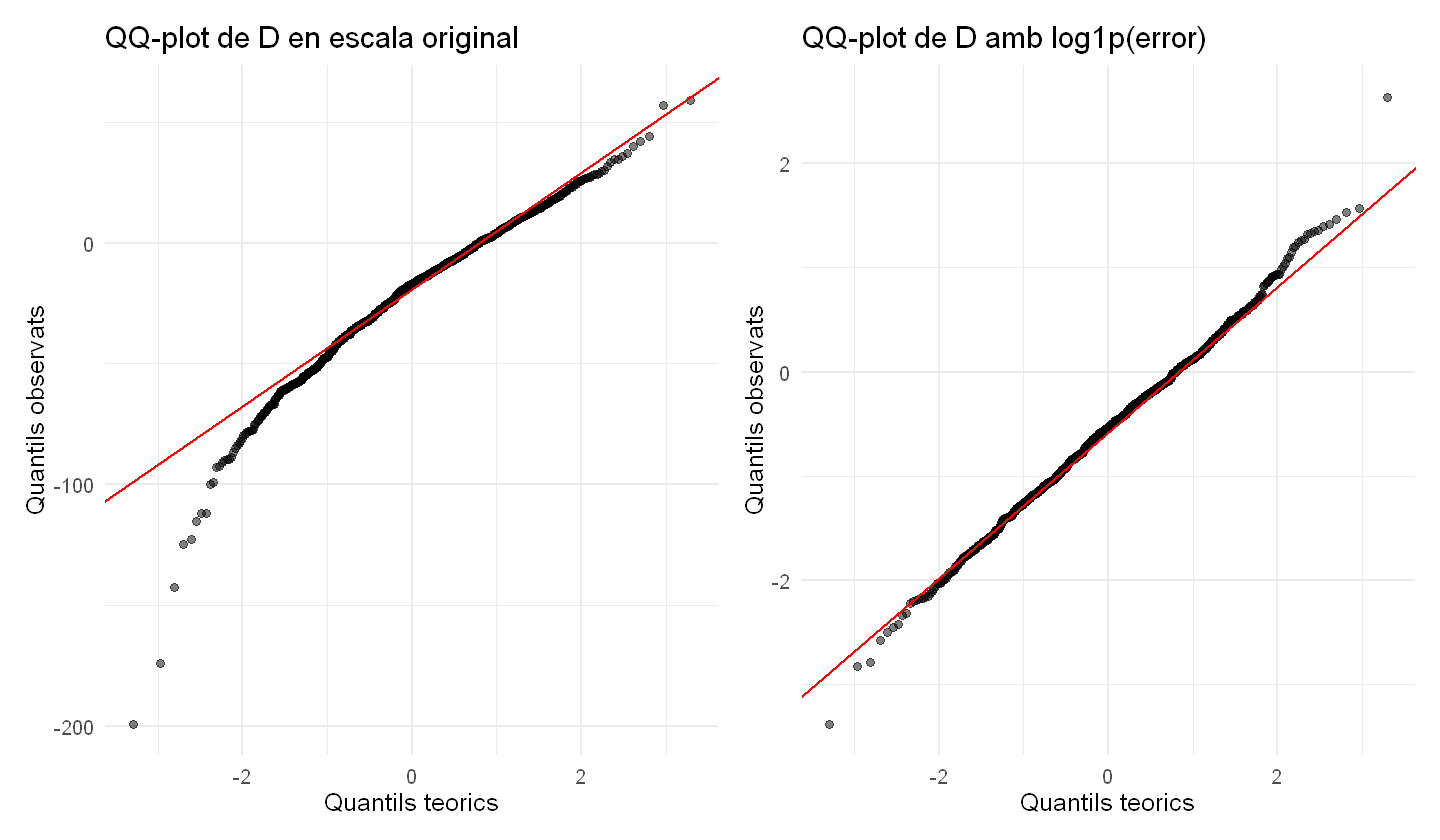

In [37]:
# Valoracio grafica i numerica de la transformacio logaritmica.
# Aquesta part es una analisi de sensibilitat, no substitueix el test principal en escala original.
dades_log <- dades_aparellades %>%
  mutate(
    log_error_5_1 = log1p(error_5_1),
    log_error_5_4 = log1p(error_5_4),
    D_log = log_error_5_1 - log_error_5_4
  )

# Test aparellat en escala logaritmica, nomes com a sensibilitat.
test_t_log <- t.test(
  dades_log$log_error_5_1,
  dades_log$log_error_5_4,
  paired = TRUE
)

# Sortida nativa de R del test en escala log.
print(test_t_log)

resum_log_models <- tibble(
  model = c(model_a, model_b),
  mitjana_aritmetica_original = c(mean(dades_log$error_5_1), mean(dades_log$error_5_4)),
  mitjana_geometrica_desplacada = c(
    exp(mean(dades_log$log_error_5_1)) - 1,
    exp(mean(dades_log$log_error_5_4)) - 1
  )
)

rao_log_5_1_vs_5_4 <- exp(mean(dades_log$D_log))
percent_canvi_log <- (rao_log_5_1_vs_5_4 - 1) * 100

resum_log_comparacio <- tibble(
  mesura = c(
    "Diferencia mitjana en log1p",
    "Rao geometrica de (1 + error): gpt-5.1 / gpt-5.4",
    "Canvi percentual aproximat de gpt-5.1 respecte gpt-5.4"
  ),
  valor = c(
    mean(dades_log$D_log),
    rao_log_5_1_vs_5_4,
    percent_canvi_log
  )
)

graf_qq_D_original <- ggplot(dades_log, aes(sample = D)) +
  stat_qq(alpha = 0.5) +
  stat_qq_line(color = "red") +
  labs(title = "QQ-plot de D en escala original", x = "Quantils teorics", y = "Quantils observats")

graf_qq_D_log <- ggplot(dades_log, aes(sample = D_log)) +
  stat_qq(alpha = 0.5) +
  stat_qq_line(color = "red") +
  labs(title = "QQ-plot de D amb log1p(error)", x = "Quantils teorics", y = "Quantils observats")

resum_log <- tibble(
  escala = c("Original", "log1p(error)"),
  diferencia_mitjana = c(mean(dades_log$D), mean(dades_log$D_log)),
  sd_diferencia = c(sd(dades_log$D), sd(dades_log$D_log))
)

graf_qq_D_original + graf_qq_D_log

taula(resum_log, digits = 6, caption = "Comparacio entre escala original i logaritmica")
taula(resum_log_models, digits = 6, caption = "Mitjanes aritmetiques i geometriques desplacades")
taula(resum_log_comparacio, digits = 6, caption = "Interpretacio de la comparacio en escala log")

# Decisio aplicada sobre l'us del log en aquest estudi.
coef_model_original <- coef(model_multiple)["modelgpt-5.4"]
coef_model_log <- coef(model_multiple_log)["modelgpt-5.4"]

millora_asimetria <- abs(resum_diagnostics_models$asimetria_residus[resum_diagnostics_models$escala == "log1p(error)"]) <
  abs(resum_diagnostics_models$asimetria_residus[resum_diagnostics_models$escala == "Original"])

mateixa_conclusio_model <- coef_model_original > 0 & coef_model_log > 0

decisio_log <- tibble(
  criteri = c(
    "Conclusio sobre el model",
    "Millora visual/numerica dels residus amb log",
    "Escala recomanada per resultat principal",
    "Paper del model logaritmic"
  ),
  resultat = c(
    ifelse(mateixa_conclusio_model,
           "Les dues escales indiquen mes error per gpt-5.4 que per gpt-5.1",
           "Les dues escales no donen exactament la mateixa lectura"),
    ifelse(millora_asimetria,
           "El log redueix l'asimetria dels residus",
           "El log no millora clarament l'asimetria dels residus"),
    "Escala original, per interpretar punts d'error cromatic",
    "Complementari: sensibilitat i inferencia multiplicativa"
  )
)

taula(decisio_log, caption = "Decisio sobre l'ajust logaritmic")

**Interpretació aplicada.** Si el QQ-plot logarítmic és més alineat que l'original, la transformació pot ajudar en la normalitat visual. Tot i això, la interpretació principal és més directa en unitats d'error cromàtic original.


### 4.6. Anàlisi gràfic de les premisses

Els QQ-plots, el Bland-Altman i els gràfics de residus indiquen si les premisses són prou raonables per interpretar els resultats. En aquest dataset, la decisió principal depèn sobretot de la distribució de les diferències aparellades i de si el patró del Bland-Altman suggereix diferències additives o dependents del nivell d'error.


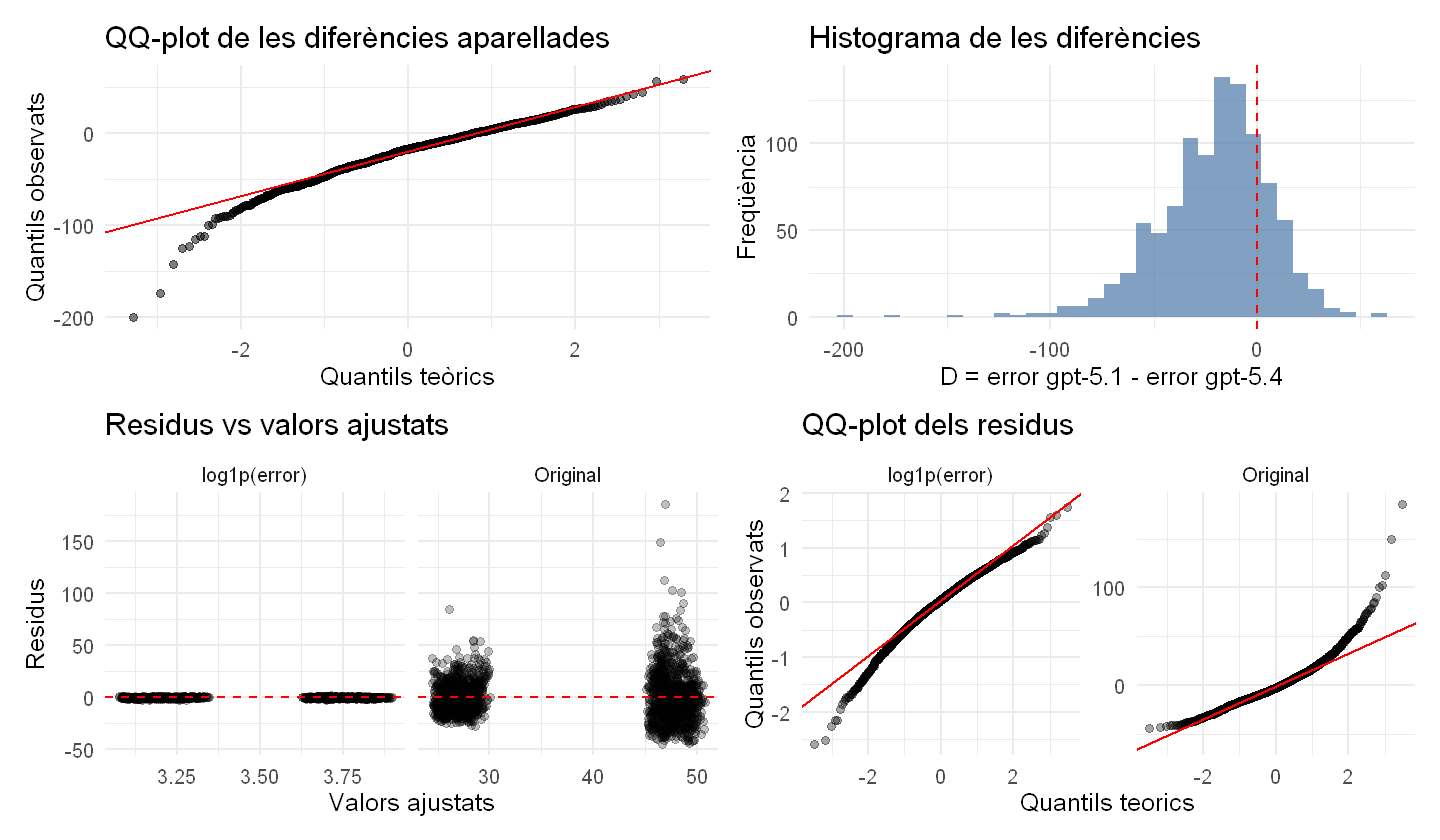

In [38]:
# Resum gràfic final de premisses.
(graf_qq_D + graf_hist_D) / (graf_residus_ajustats + graf_qq_residus)


## 5. Discussió

### 5.1. Interpretació dels resultats

El model amb menor error mitjà es determina a partir de la diferència aparellada \(D\). Si \(D < 0\), **gpt-5.1** té menor error mitjà; si \(D > 0\), **gpt-5.4** té menor error mitjà. La magnitud de la diferència s'ha d'interpretar en unitats d'error cromàtic.

La relació amb `chroma` s'avalua amb correlacions, buckets de chroma i models lineals simples. Si les pendents són positives, els colors amb més chroma tendeixen a presentar més error.

### 5.2. Relació amb les hipòtesis

La hipòtesi principal contrasta si la diferència mitjana entre models és zero. El p-value del t-test aparellat indica si la diferència observada és compatible amb una diferència mitjana nul·la en aquest disseny aparellat.

### 5.3. Limitacions de l'estudi

- La informació sobre prompt, mida, format i compressió no apareix al CSV: **PENDENT**.
- No es pot verificar des del CSV si hi ha aleatorietat estricta en la selecció dels colors.
- El prompt podria introduir biaixos no observats.
- La mida mostral és gran per a la comparació, però limitada al conjunt d'imatges disponible.
- Les premisses s'han validat principalment de forma gràfica.
- L'error depèn de l'espai de color utilitzat i aquí s'analitza l'error ja disponible al CSV.

### 5.4. Implicacions i conseqüències

Si un model presenta menor error i menor variabilitat, és més adequat per a tasques on cal estimar colors amb precisió. El paper del `chroma` és important perquè pot indicar que els colors més saturats requereixen més control experimental o una estratègia de predicció més precisa.


## 6. Conclusions

Les conclusions finals s'obtenen directament de les taules del notebook:

- El model amb menor error mitj? ?s el que queda indicat pel signe de \(D\).
- La significaci? estad?stica dep?n del p-value del t-test aparellat.
- El `chroma` pot tenir relaci? amb l'error si les correlacions i pendents s?n diferents de zero.
- Els models lineals s?n adequats com a aproximaci? descriptiva i inferencial b?sica, sempre interpretant els diagn?stics gr?fics.
- La transformacio logaritmica **no substitueix l'analisi principal**. S'utilitza nomes com a sensibilitat; si es reporta, s'ha d'interpretar amb mitjanes geometriques desplacades i raons, no amb mitjanes aritmetiques.

In [39]:
# Conclusio automatica breu basada en els resultats calculats.
conclusio_automatica <- tibble(
  element = c(
    "Model amb menor error mitja",
    "Diferencia mitjana D",
    "IC 95% inferior",
    "IC 95% superior",
    "p-value",
    "Interpretacio de significacio"
  ),
  resultat = c(
    model_millor,
    round(diferencia_mitjana, 4),
    round(ic_95[1], 4),
    round(ic_95[2], 4),
    format.pval(p_value_t, digits = 4, eps = 0.0001),
    ifelse(p_value_t < 0.05, "Hi ha evidencia de diferencia mitjana", "No hi ha evidencia suficient de diferencia mitjana")
  )
)

taula(conclusio_automatica, caption = "Conclusio automatica del contrast principal")

element,resultat
Model amb menor error mitja,gpt-5.1
Diferencia mitjana D,-20.6581
IC 95% inferior,-22.3471
IC 95% superior,-18.9691
p-value,< 0.0001
Interpretacio de significacio,Hi ha evidencia de diferencia mitjana


## 7. Recomanacions per a futurs estudis

- Ampliar la mostra amb nous colors i condicions visuals.
- Registrar i controlar millor els prompts utilitzats.
- Incloure variables de mida, format i compressió de les imatges.
- Estudiar altres variables de color a més del `chroma`.
- Validar els resultats amb altres datasets.


## 8. Referències

- R Core Team. Documentació de la funció `t.test()`.
- R Core Team. Documentació de la funció `lm()`.
- Wickham et al. Llibreries `tidyverse`, `ggplot2`, `dplyr` i `tidyr`.
- Robinson, Hayes i Couch. Llibreria `broom`.
- Xie. Llibreria `knitr`.
- Pedersen. Llibreria `patchwork`.


## 9. Annexos

### 9.1. Codi en R

Tot el codi complet de l'anàlisi està inclòs dins de les cel·les anteriors d'aquest notebook. No s'ha utilitzat cap script extern ni `analysis_functions.R`.


In [40]:
# Informació de sessió per garantir reproductibilitat.
sessionInfo()


R version 4.5.3 (2026-03-11 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=Spanish_Spain.utf8  LC_CTYPE=Spanish_Spain.utf8   
[3] LC_MONETARY=Spanish_Spain.utf8 LC_NUMERIC=C                  
[5] LC_TIME=Spanish_Spain.utf8    

time zone: Europe/Madrid
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.2 knitr_1.51      broom_1.0.12    lubridate_1.9.5
 [5] forcats_1.0.1   stringr_1.6.0   dplyr_1.2.1     purrr_1.2.2    
 [9] readr_2.2.0     tidyr_1.3.2     tibble_3.3.1    ggplot2_4.0.3  
[13] tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] generics_0.1.4     lattice_0.22-9     stringi_1.8.7      hms_1.1.4         
 [5] digest_0.6.39      magrittr_2.0.5     evaluate_1.0.5     grid_4.5.3        
 [9] timechange_0.4.0   RColorBrewer_1.1-3 pbdZMQ_0.3-

### 9.2. Dades utilitzades


In [41]:
# Resum final de les dades utilitzades i criteris de filtratge.
annex_dades <- tibble(
  camp = c(
    "Ruta utilitzada",
    "Models analitzats",
    "Variable resposta Y",
    "Variable explicativa X",
    "Covariable Z",
    "Criteri de filtratge",
    "Nombre final d'observacions",
    "Nombre de parelles"
  ),
  valor = c(
    ruta_csv,
    paste(model_a, "i", model_b),
    "error_cromatic",
    "model",
    "chroma",
    "model %in% c('gpt-5.1', 'gpt-5.4') i status == 'ok'",
    nrow(dades_models),
    nrow(dades_aparellades)
  )
)

taula(annex_dades, caption = "Dades utilitzades a l'estudi")


camp,valor
Ruta utilitzada,C:/Users/AdriàSebastià/Documents/dev/color-llm-benchmark/recollida-dades/experiments/soroll/results/sample_colors_tots_models_actual.csv
Models analitzats,gpt-5.1 i gpt-5.4
Variable resposta Y,error_cromatic
Variable explicativa X,model
Covariable Z,chroma
Criteri de filtratge,"model %in% c('gpt-5.1', 'gpt-5.4') i status == 'ok'"
Nombre final d'observacions,2000
Nombre de parelles,1000
